[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__Home__](../README.md)

# Divvy: Bike Sharing Forecast
## RNN: Modeling & Validation

__Dataset:__ [Divvy Data](https://divvybikes.com/system-data) \
__Author:__ [Dmitry Luchkin](https://www.linkedin.com/in/dmitry-luchkin/) \
__Date:__ March 2025

> **Attention**
>
> The data utilized in this project were sourced from the official public data provided by Divvy. All analysis, results, and insights presented in this notebook were conducted and formulated by Dmitry Luchkin. I declare that I am not affiliated with Divvy, Lyft, the City of Chicago, or any associated organizations. The views and interpretations expressed herein are solely my own and do not represent the positions or policies of these entities.

### Notebooks <a class="anchor" name='notebooks'></a>

+ [Initial Data Exploration](./01_Divvy_data_exploration.ipynb)
+ [Data Cleaning](./02_Divvy_data_cleaning.ipynb)
+ [Exploratory Data Analysis](./03_Divvy_exploratory_data_analysis.ipynb)
+ [Feature Engineering](./04_Divvy_feature_engineering.ipynb)
+ Modeling & Validation:
  - [XGBoost: Modeling & Validation](./05.1_Divvy_modeling_xgboost.ipynb)
  - __[RNN: Modeling & Validation](./05.2_Divvy_modeling_rnn.ipynb)__
  - [ARIMAX: Modeling & Validation](./05.3_Divvy_modeling_arimax.ipynb)
  - [MSTL: Modeling & Validation](./05.4_Divvy_modeling_mstl.ipynb)
  - [Ensemble: Modeling & Validation](./05.5_Divvy_modeling_ensemble.ipynb)
+ [Forecasting](./06_Divvy_forecasting.ipynb)

### Import Libraries <a name='import-libraries'></a>

In [1]:
import os 
import sys
import pickle
import warnings

import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series

warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
sys.path.append('../02_scripts/')

# import project code
from utils.plotting import notebook_setup
from utils.plotting.notebook_setup import TRAIN_COLOR, TEST_COLOR, FORECAST_COLOR
from utils.plotting.viz import plot_trips, plot_feature_importance, distplot, check_residuals, plot_combos
from utils.model.tools import add_lags, make_features, get_best_model
from utils.model.seed import set_seed
from utils.model.xgb import train_validate_xgb, find_best_combo, xgb_run
from utils.model.rnn import train_validate_rnn

2025-04-24 14:32:09.670024: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Loading Data <a name='loading-data'></a>

In [3]:
train_filename = "../00_data/02_processed/divvy_train.pkl"
test_filename = "../00_data/02_processed/divvy_test.pkl"
train = None
test = None
# load training set
with open(train_filename, 'rb') as f:
        train = pickle.load(f)

# load test set
with open(test_filename, 'rb') as f:
        test = pickle.load(f)

#### Daily total number of bike trips

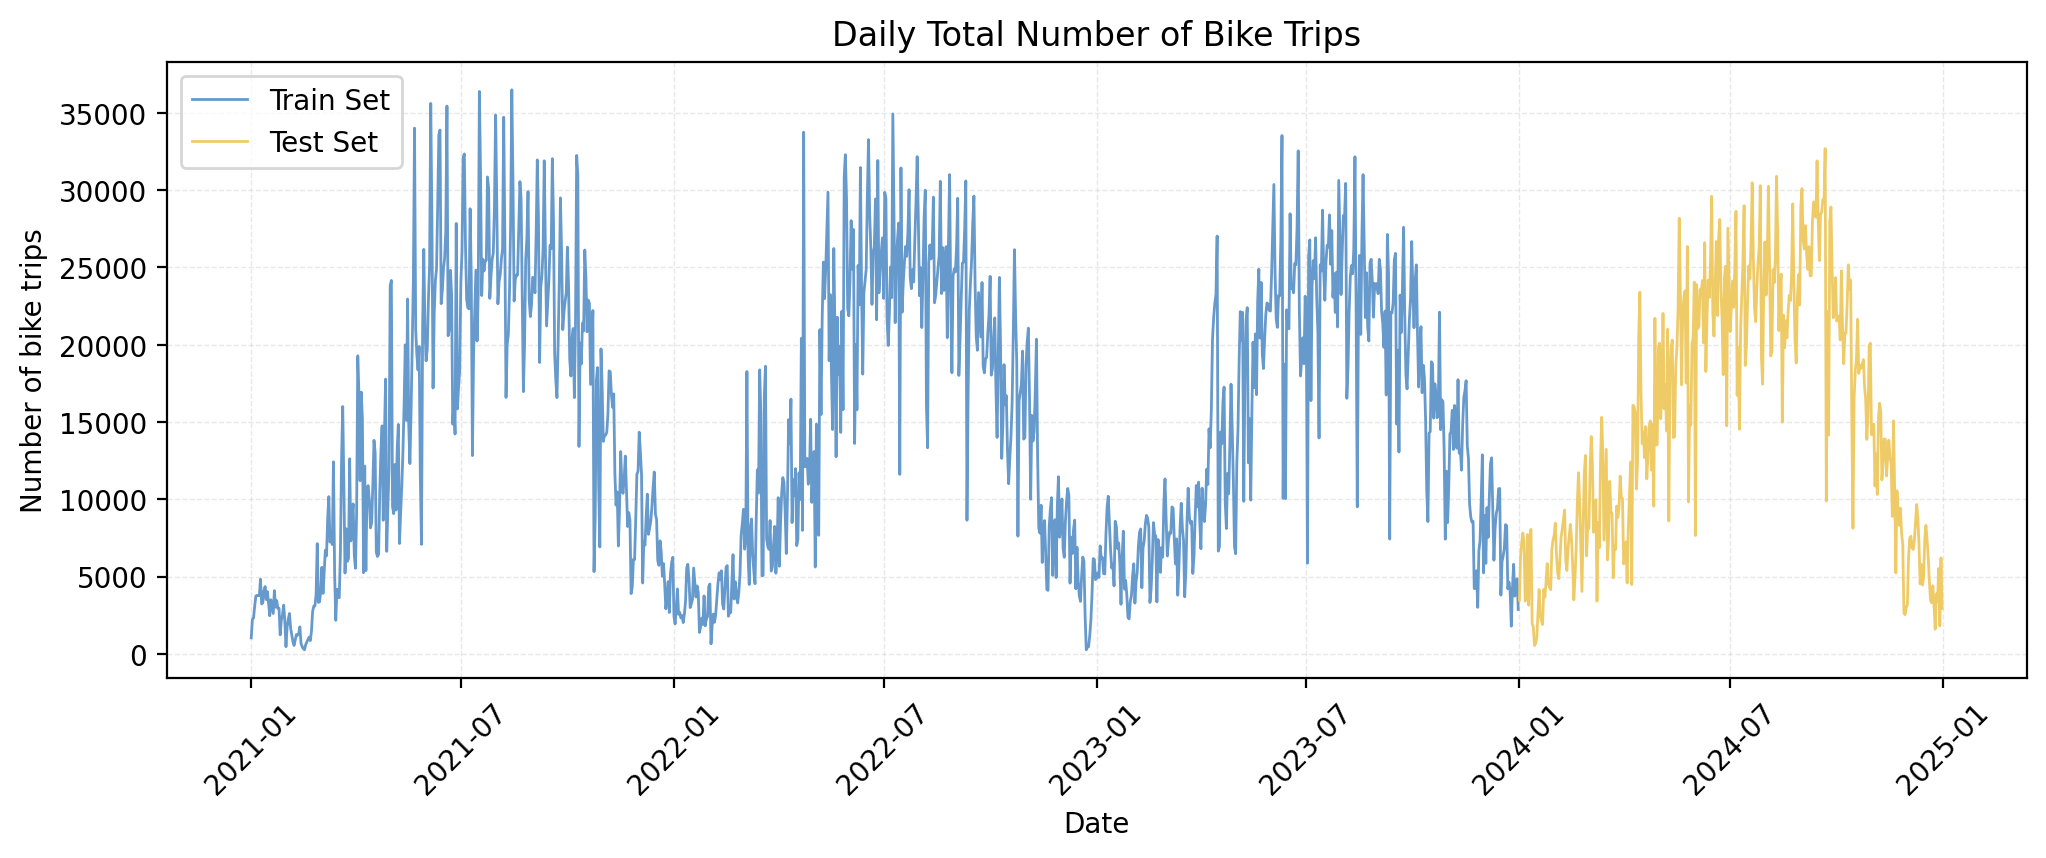

In [4]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_trips(ax, train["total_rides"], test["total_rides"], title="Daily Total Number of Bike Trips")
plt.show()

#### Daily sub-total number of bike trips

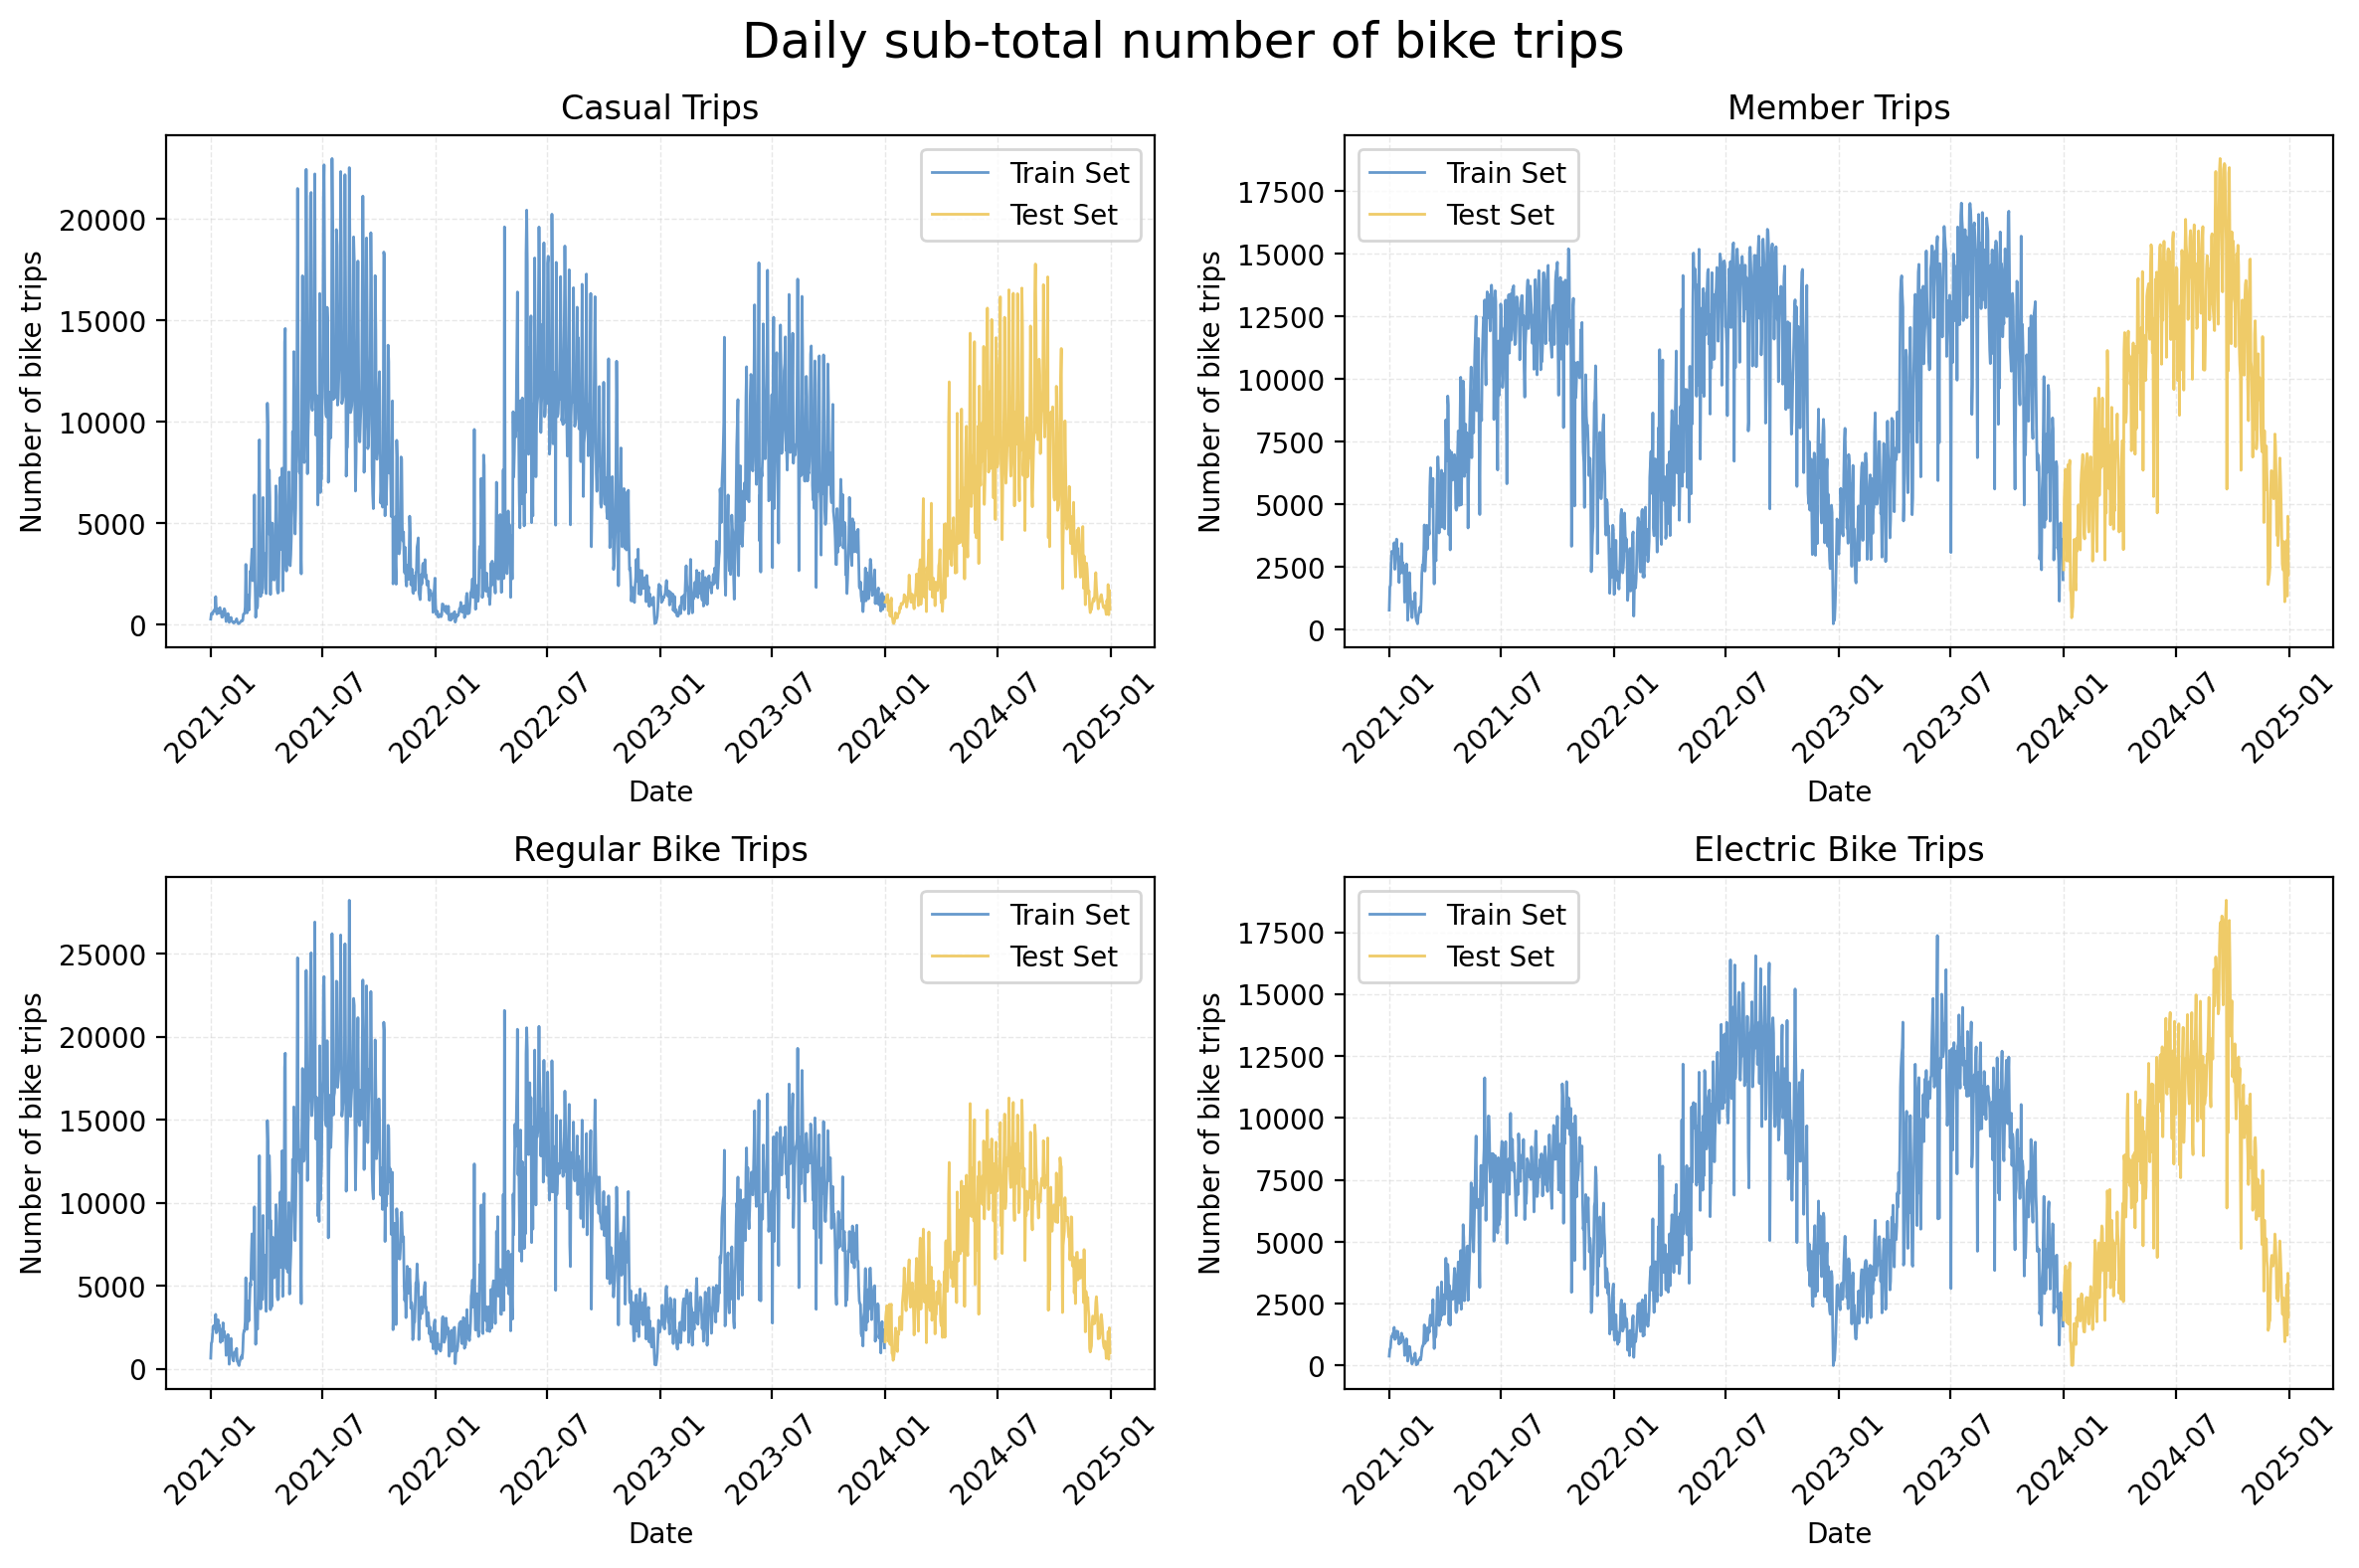

In [5]:
_, ax = plt.subplots(2, 2, figsize=(12, 8))
plot_trips(ax[0, 0], train["casual_total"], test["casual_total"], title="Casual Trips")
plot_trips(ax[0, 1], train["member_total"], test["member_total"], title="Member Trips")
plot_trips(ax[1, 0], train["regular_total"], test["regular_total"], title="Regular Bike Trips")
plot_trips(ax[1, 1], train["electric_total"], test["electric_total"], title="Electric Bike Trips")
plt.suptitle("Daily sub-total number of bike trips", fontsize=18)
plt.tight_layout()
plt.show()

#### Daily number of trips by bike type and user type

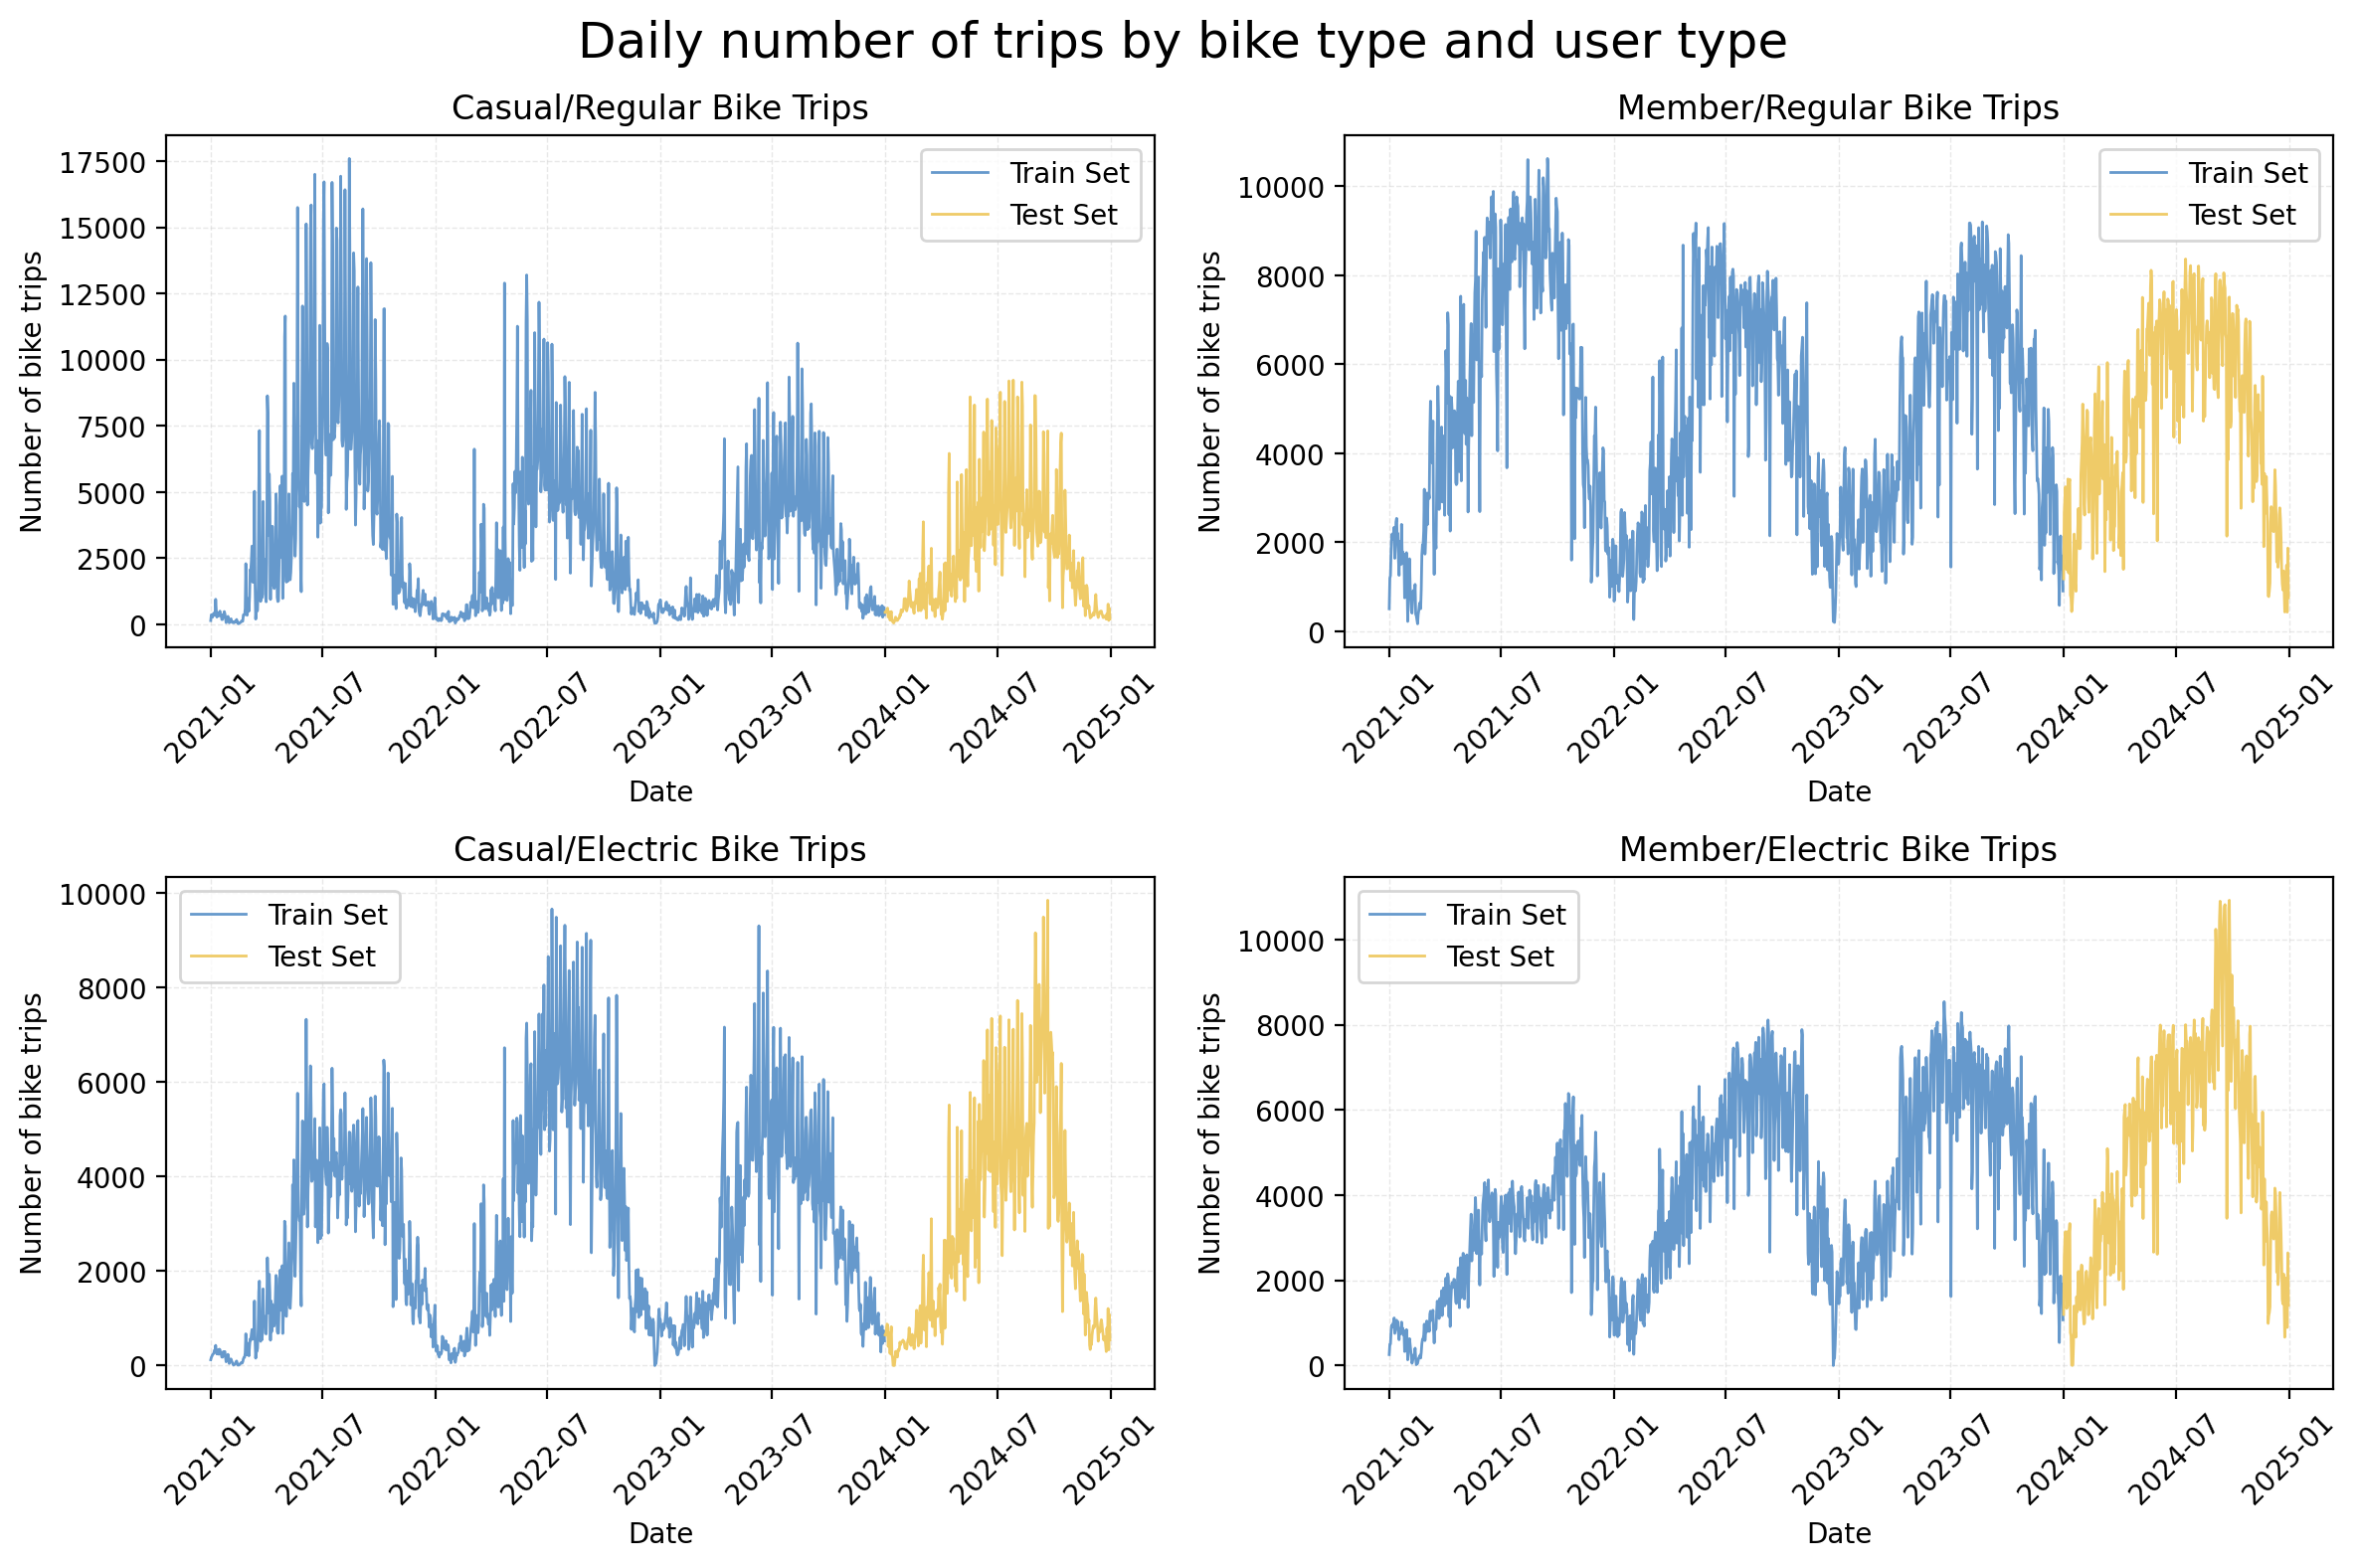

In [6]:
_, ax = plt.subplots(2, 2, figsize=(12, 8))
plot_trips(ax[0, 0], train["casual_regular_bike"], test["casual_regular_bike"], title="Casual/Regular Bike Trips")
plot_trips(ax[0, 1], train["member_regular_bike"], test["member_regular_bike"], title="Member/Regular Bike Trips")
plot_trips(ax[1, 0], train["casual_electric_bike"], test["casual_electric_bike"], title="Casual/Electric Bike Trips")
plot_trips(ax[1, 1], train["member_electric_bike"], test["member_electric_bike"], title="Member/Electric Bike Trips")
plt.suptitle("Daily number of trips by bike type and user type", fontsize=18)
plt.tight_layout()
plt.show()

### Hierarchical Forecasting

Hierarchical forecasting aims to produce forecasts that are both accurate and consistent across levels of the hierarchy.

Two primary approaches are used for hierarchical forecasting:

+ __Bottom-Up Approach__
  The bottom-up method starts by forecasting the most granular (lowest-level) series independently. These forecasts are then aggregated upward to obtain predictions for higher levels in the hierarchy.

+ __Top-Down Approach__
  The top-down method begins by forecasting the top-level (aggregate) series. These forecasts are then disaggregated downward based on historical proportions or predictive models.

In [7]:
rnn_mae_scores = {
    "bottom-up": {
        "mae": {
            "total_rides": None,
            "regular_total": None,
            "electric_total": None,
            "casual_total": None,
            "member_total": None,
            "casual_regular_bike": None,
            "member_regular_bike": None,
            "casual_electric_bike": None,
            "member_electric_bike": None
            }},
    "top-down": {
        "mae":{
            "total_rides": None,
            "regular_total": None,
            "electric_total": None,
            "casual_total": None,
            "member_total": None,
            "casual_regular_bike": None,
            "member_regular_bike": None,
            "casual_electric_bike": None,
            "member_electric_bike": None
            }}
}

#### Top-Down

Get to know the best window size.

In [8]:
from tqdm.notebook import tqdm
import itertools

In [67]:
def test_rnn_window_size(train, test, target_name, window_sizes, seeds):
    """"
    Evaluates the performance of an RNN/LSTM model across multiple window sizes and random seeds,
    and selects the best-performing window size based on average MAE.

    Parameters:
        train (pd.DataFrame): Training dataset including the target and all necessary features.
        test (pd.DataFrame): Test dataset with the same structure as the training set.
        target_name (str): Name of the target variable to forecast.
        window_sizes (list of int): List of window sizes (number of lag steps) to evaluate.
        seeds (list of int): List of random seeds to assess robustness and stability.

    Returns:
        tuple:
            best_window_size (int): The window size with the lowest average MAE.
            best_preds (list of np.ndarray): List of predictions (one per seed) for the best window size.
            fun_out (list of dict): Detailed results for each window size, containing:
                - 'window_size': int, the window size tested
                - 'mae_mean': float, mean MAE across seeds
                - 'mae_std': float, standard deviation of MAE
                - 'forecast_mean': np.ndarray, average forecast across seeds
    """
    rnn_forecasts = {ws: {"mae": [], "y_pred": []} for ws in window_sizes}
    param_grid = list(itertools.product(seeds, window_sizes))
    i = 0
    for seed, window_size in tqdm(param_grid):

        if i == 0:
            tqdm.write("")
            tqdm.write(f"BEST RNN/LSTM WINDOW SIZE FOR `{target_name}`")
            tqdm.write('')
            header = f"| {"N.":<2} | {'Random Seed':<20} | {"Window Size":<20} | {"MAE":<10} |"
            tqdm.write('-' * len(header))
            tqdm.write(header)
            tqdm.write('-' * len(header))
        
        set_seed(seed, verbose=False)
        _, _, _, _, rnn_pred_y = train_validate_rnn(train, test, target_name, H=window_size, verbose=0)
        mae = mean_absolute_error(test[target_name], rnn_pred_y)
        rnn_forecasts[window_size]["mae"].append(mae)
        rnn_forecasts[window_size]["y_pred"].append(rnn_pred_y)

        tqdm.write(f"| {(i+1):<2} | {seed:<20} | {window_size:<20} | {mae:<10.2f} |")
        tqdm.write('-' * len(header))
        
        i += 1

    print("\nResults:\n")
    header = f"   | {"Window Size":<20} | {"Mean MAE":<30} |"
    tqdm.write('-' * len(header))
    tqdm.write(header)
    tqdm.write('-' * len(header))

    fun_out = []
    
    for window_size, item in rnn_forecasts.items():
        mean_mae = np.mean(item["mae"])
        mae_std = np.std(item["mae"])
        mean_y_pred = np.mean(item["y_pred"], axis=0)
        
        fun_out.append({"window_size": window_size,
                        "mae_mean": mean_mae,
                        "mae_std": mae_std,
                        "forecast_mean": mean_y_pred})

    best_window_size = min(fun_out, key=lambda x: x["mae_mean"])["window_size"]

    for item in sorted(fun_out, key=lambda x: x["mae_mean"]):
        mark = " "
        if item["window_size"] == best_window_size:
            mark = "*"
        mae = f"{item["mae_mean"]:.2f}±{item["mae_std"]:.2f}"
        print(f" {mark} | {item["window_size"]:<20} | {mae:<30} |")
        print("-" * len(header))

    print(f"\nBest window size for {target_name}: {best_window_size}\n")
    best_preds = rnn_forecasts[best_window_size]["y_pred"]

    return best_window_size, best_preds, fun_out

def plot_window_size(results, target_name):
    plt.figure(figsize=(8, 4))
    plt.errorbar([str(item["window_size"]) for item in results], [item["mae_mean"] for item in results], 
                 yerr=[item["mae_std"] for item in results], fmt='o', 
                 capsize=5, color='blue', ecolor='gray', elinewidth=2)
    plt.title(f"RNN: The best window size selection for {target_name}")
    plt.xlabel("Window Size")
    plt.ylabel("Mean MAE")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
SEEDs = [0, 42, 123, 777, 2025]
window_sizes = [30, 60, 90, 120]
total_window_size, total_forecast, total_results = test_rnn_window_size(train, test, "total_rides", 
                                                        window_sizes=window_sizes, seeds=SEEDs)

  0%|          | 0/20 [00:00<?, ?it/s]


BEST RNN/LSTM WINDOW SIZE FOR `total_rides`

-----------------------------------------------------------------
| N. | Random Seed          | Window Size          | MAE        |
-----------------------------------------------------------------
| 1  | 0                    | 30                   | 1704.97    |
-----------------------------------------------------------------
| 2  | 0                    | 60                   | 1693.23    |
-----------------------------------------------------------------
| 3  | 0                    | 90                   | 1637.80    |
-----------------------------------------------------------------
| 4  | 0                    | 120                  | 1682.57    |
-----------------------------------------------------------------
| 5  | 42                   | 30                   | 1718.35    |
-----------------------------------------------------------------
| 6  | 42                   | 60                   | 1677.76    |
------------------------------

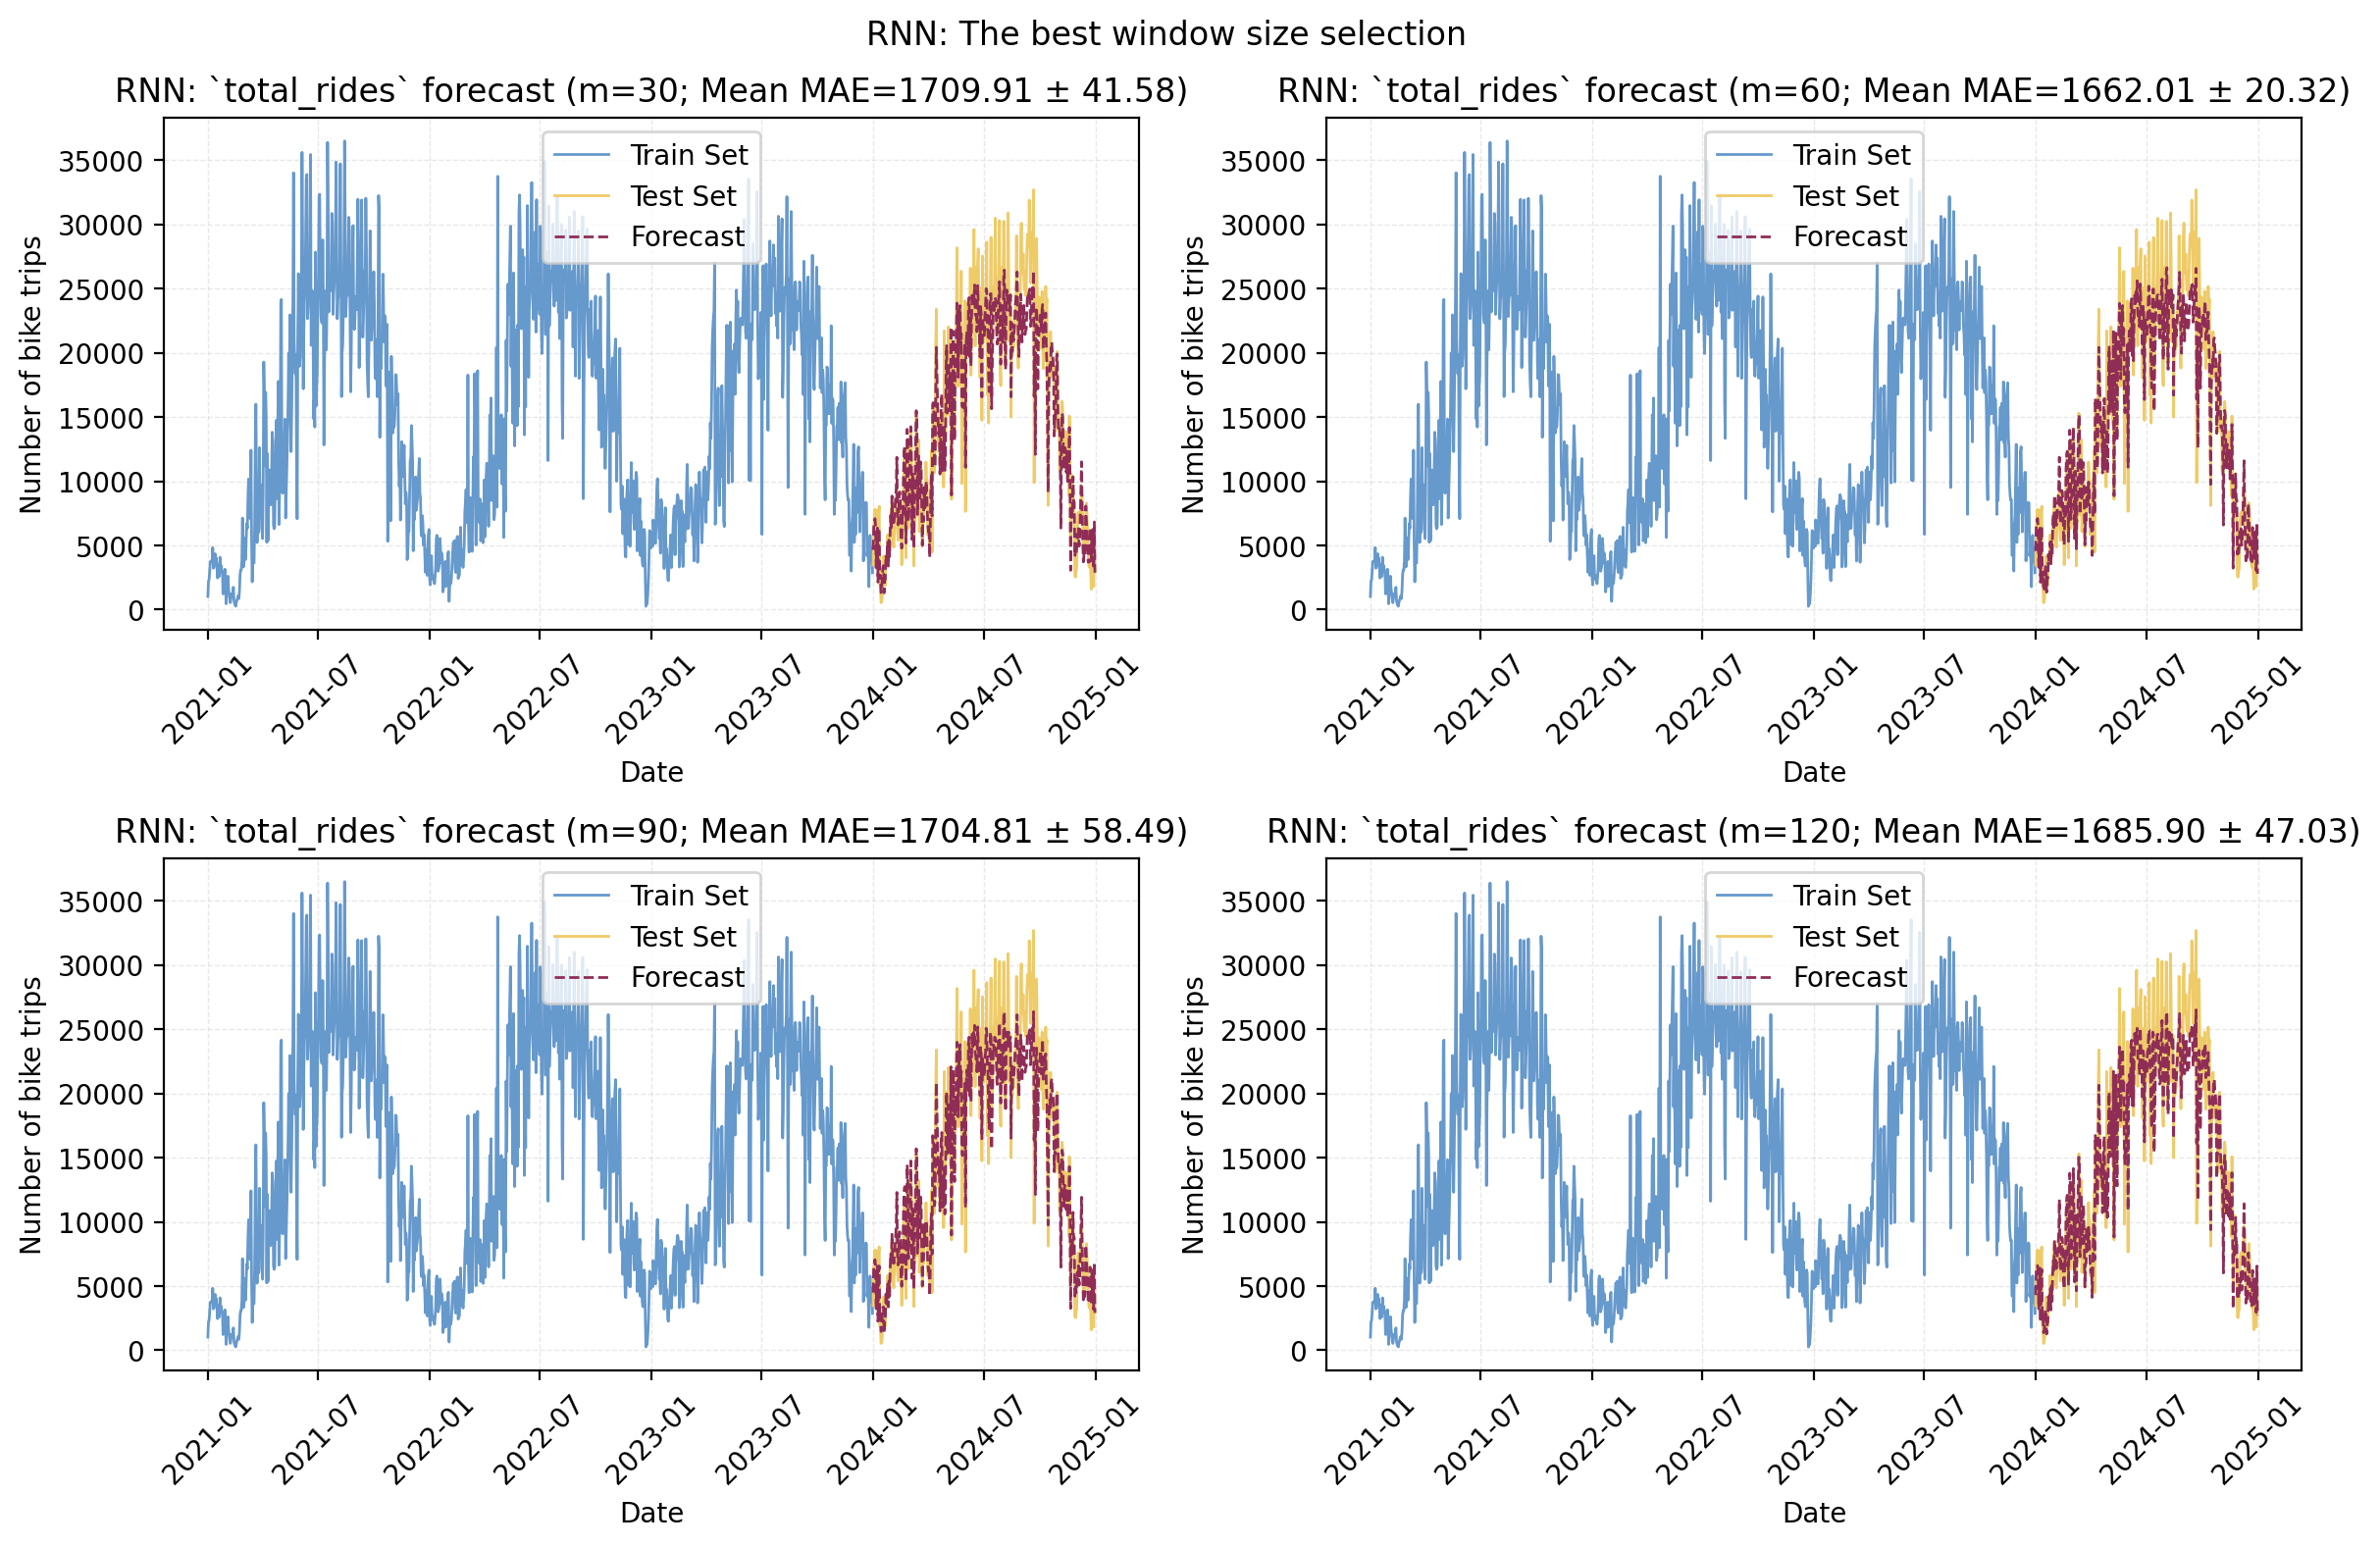

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')

for i in range(0, 4):
    m = window_sizes[i]
    rnn_total_forecast_m = [item["forecast_mean"] for item in total_results if item["window_size"] == m][0]
    rnn_mae_score_m = [item["mae_mean"] for item in total_results if item["window_size"] == m][0]
    rnn_std_m = [item["mae_std"] for item in total_results if item["window_size"] == m][0]

    plot_trips(train=train["total_rides"], 
               test=test["total_rides"],
               forecast=pd.DataFrame(rnn_total_forecast_m, test.index),
               title=f"RNN: `total_rides` forecast (m={m}; Mean MAE={rnn_mae_score_m:.2f} ± {rnn_std_m:.2f})",
               ax=ax[int(i // 2), int(i % 2 == 1)])

plt.suptitle("RNN: The best window size selection")
plt.tight_layout()
plt.show()

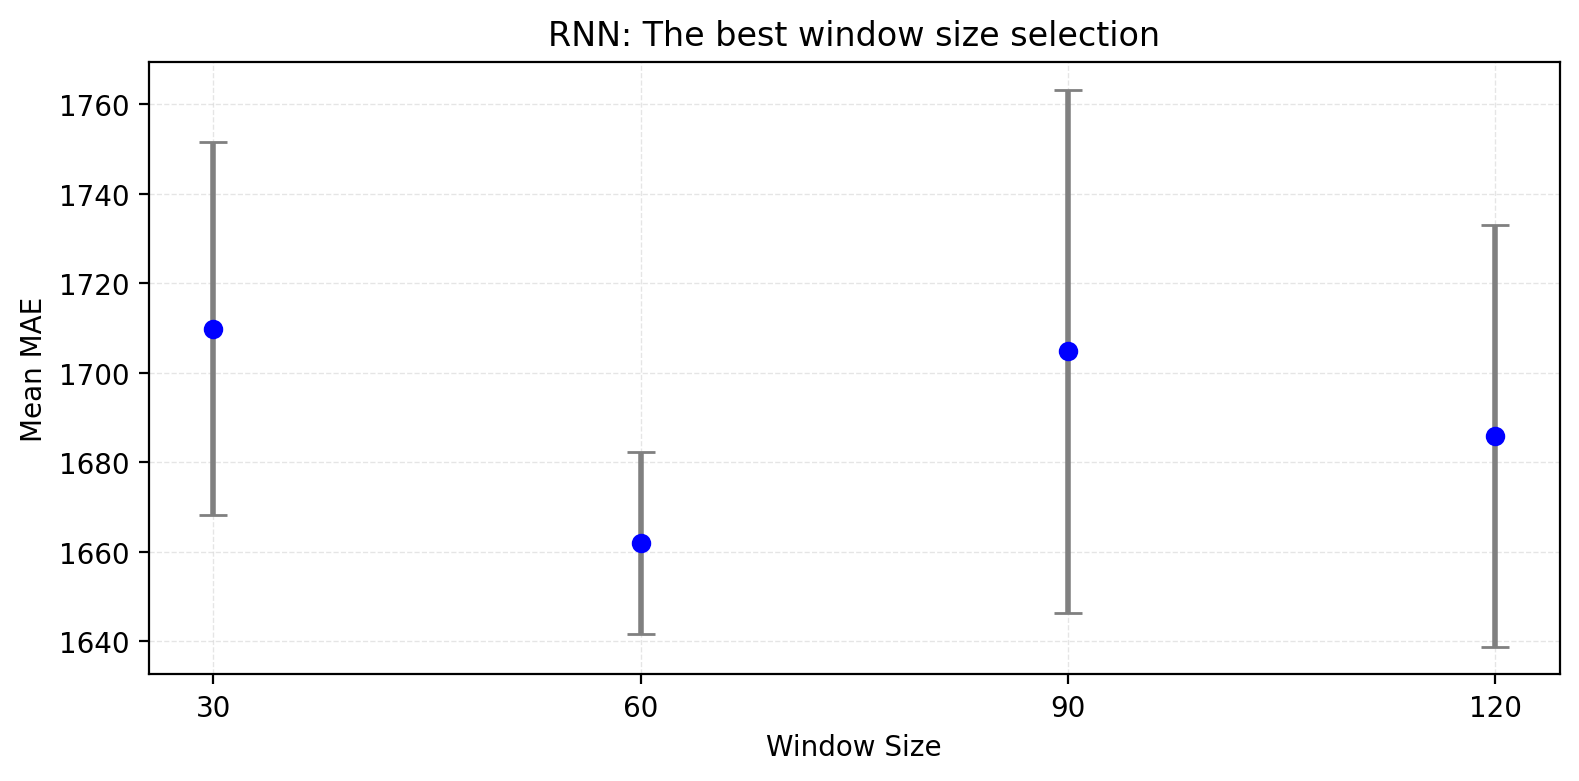

In [36]:
plt.figure(figsize=(8, 4))
plt.errorbar([str(item) for item in window_sizes], [item["mae_mean"] for item in total_results], 
             yerr=[item["mae_std"] for item in total_results], fmt='o', 
             capsize=5, color='blue', ecolor='gray', elinewidth=2)
plt.title("RNN: The best window size selection")
plt.xlabel("Window Size")
plt.ylabel("Mean MAE")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
# set seed
set_seed(42)

Seed 42 has been set.


In [40]:
#!!! re-TRAIN the model with the best window size

_, _, _, _, rnn_td_total_forecast = \
            train_validate_rnn(train, test, "total_rides", H=total_window_size, verbose=0)

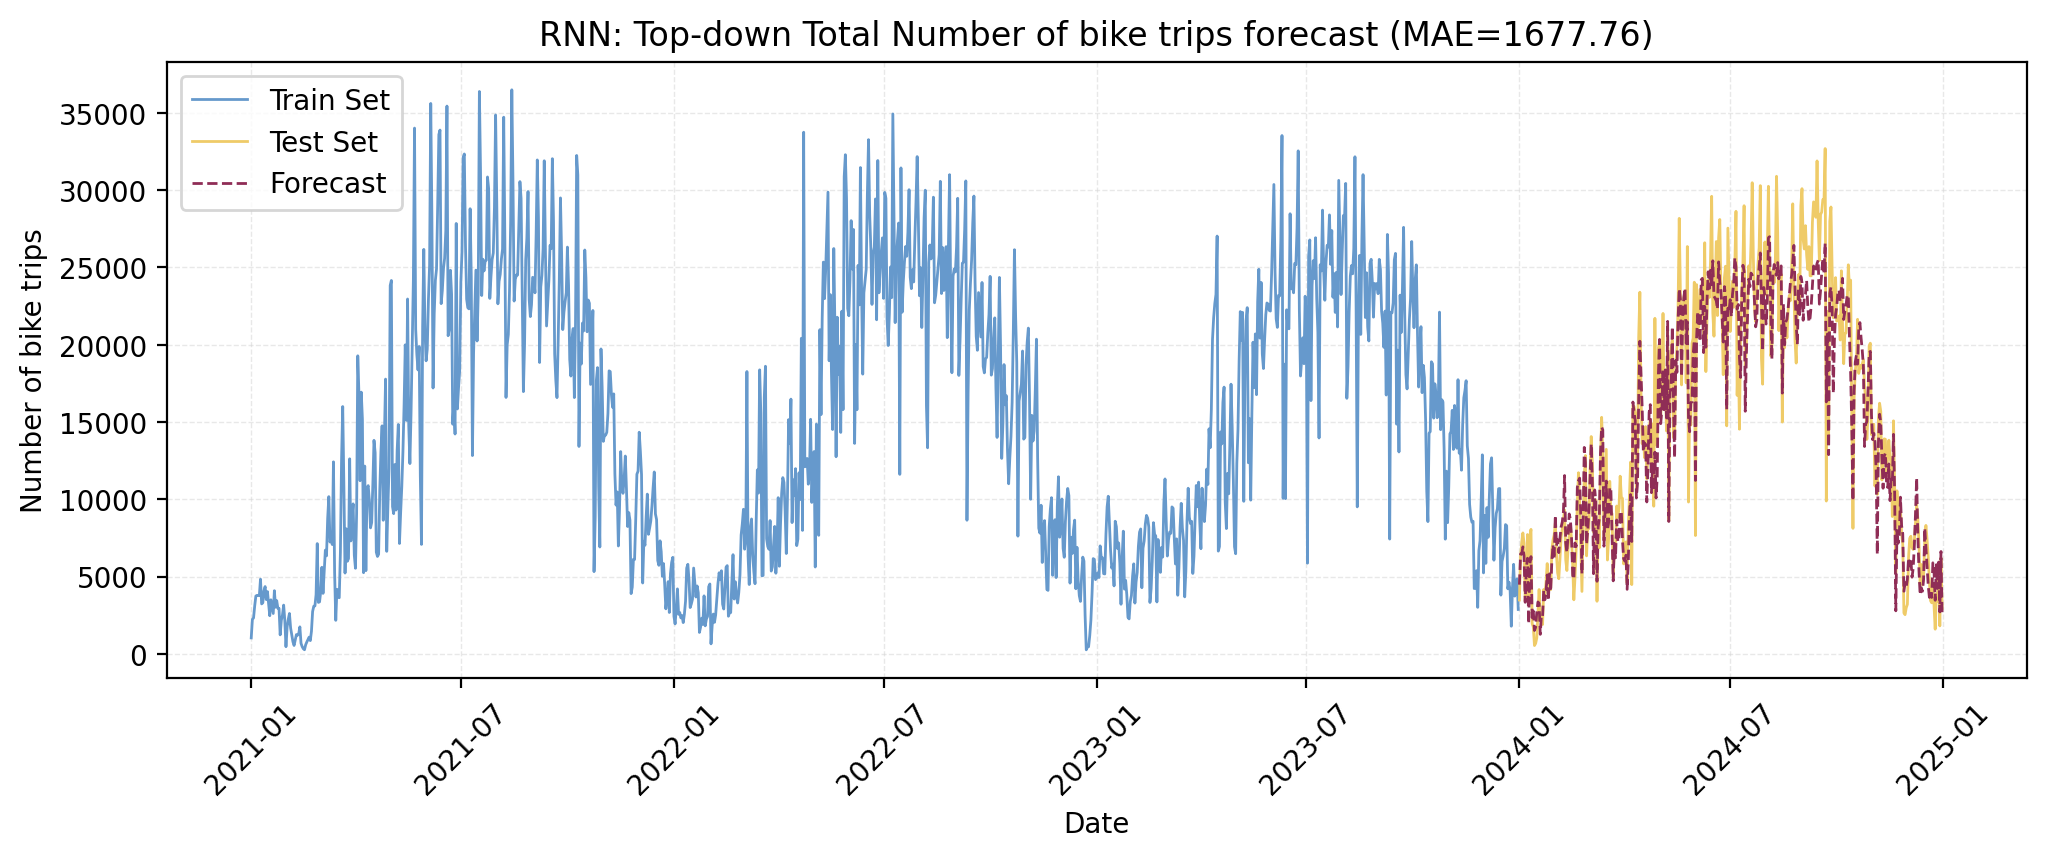

In [41]:
rnn_td_total_mae = mean_absolute_error(test["total_rides"], rnn_td_total_forecast)

# Viz the forecast
_, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_trips(ax, train["total_rides"], test["total_rides"], 
           forecast=pd.DataFrame(rnn_td_total_forecast, index=test.index),
           title=f"RNN: Top-down Total Number of bike trips forecast (m={total_window_size}, MAE={rnn_td_total_mae:.2f})")

plt.show()

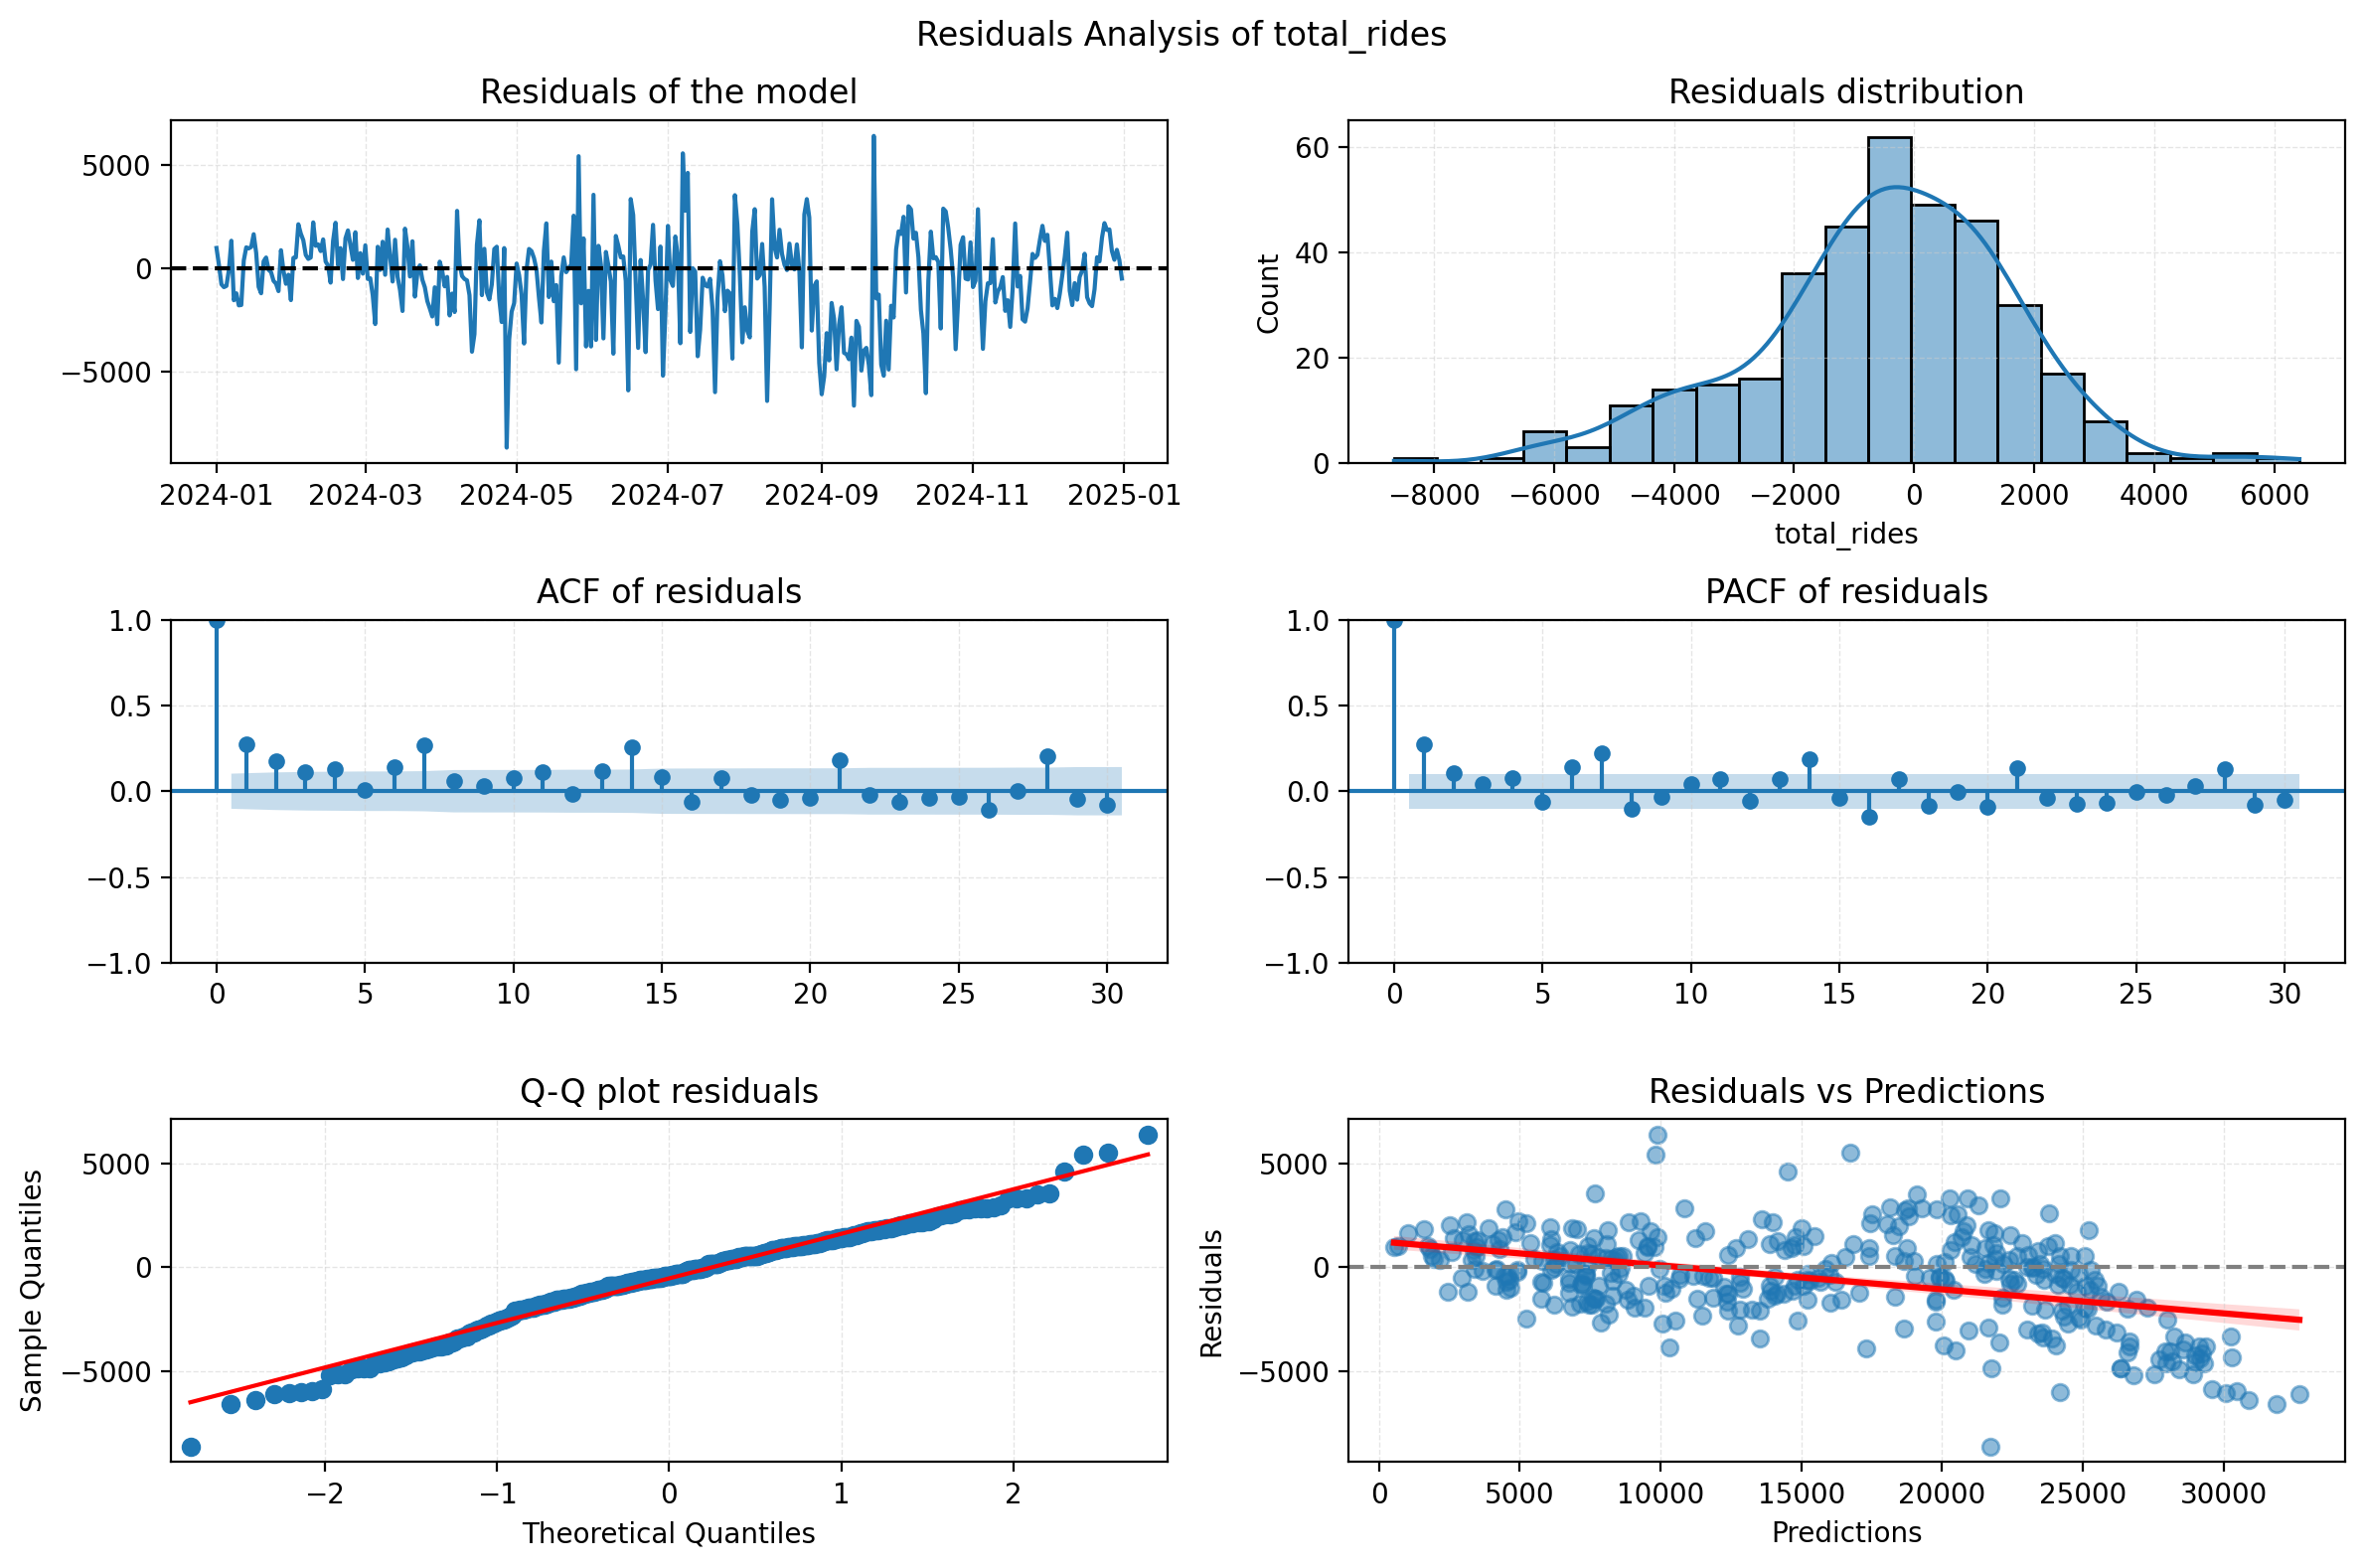


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  88.0821     0.0000
Residuals are autocorrelated

-- Dickey–Fuller test --
ADF Statistic: -3.3507252207355833
p-value: 0.012757818390176185
Time series is stationary

-- KPSS test --
ADF Statistic: 0.17975943176263276
p-value: 0.023590213089012713
Time series is non stationary


In [43]:
check_residuals(rnn_td_total_forecast, test["total_rides"], "total_rides")

In [44]:
rnn_mae_scores['top-down']['mae']['total_rides'] =  rnn_td_total_mae

##### Down-level forecast distribution

In [45]:
train_totals = train[['casual_regular_bike', 'member_regular_bike', 'casual_electric_bike',
       'member_electric_bike']].sum()
props =  train_totals / train_totals.sum()
props

casual_regular_bike    0.2164
member_regular_bike    0.3312
casual_electric_bike   0.1902
member_electric_bike   0.2621
dtype: float64

In [46]:
rnn_td_bottom_forecast = pd.DataFrame({
    node: rnn_total_forecast * prop for node, prop in props.items()
})
rnn_td_bottom_forecast.index = test.index
rnn_td_bottom_forecast.head()

,casual_regular_bike,member_regular_bike,casual_electric_bike,member_electric_bike
2024-01-01,992.5062,"1,518.8251",872.3454,"1,202.0634"
2024-01-02,"1,397.5402","2,138.6457","1,228.3427","1,692.6160"
2024-01-03,"1,441.8691","2,206.4819","1,267.3048","1,746.3045"
2024-01-04,"1,487.6370","2,276.5203","1,307.5317","1,801.7358"
2024-01-05,"1,364.6143","2,088.2595","1,199.4031","1,652.7381"


In [47]:
rnn_td_casual_regular_mae = mean_absolute_error(test["casual_regular_bike"], rnn_td_bottom_forecast["casual_regular_bike"])
rnn_td_member_regular_mae = mean_absolute_error(test["member_regular_bike"], rnn_td_bottom_forecast["member_regular_bike"])
rnn_td_casual_electric_mae = mean_absolute_error(test["casual_electric_bike"], rnn_td_bottom_forecast["casual_electric_bike"])
rnn_td_member_electric_mae = mean_absolute_error(test["member_electric_bike"], rnn_td_bottom_forecast["member_electric_bike"])

In [48]:
rnn_mae_scores['top-down']['mae']['casual_regular_bike'] = rnn_td_casual_regular_mae
rnn_mae_scores['top-down']['mae']['member_regular_bike'] = rnn_td_member_regular_mae
rnn_mae_scores['top-down']['mae']['casual_electric_bike'] = rnn_td_casual_electric_mae
rnn_mae_scores['top-down']['mae']['member_electric_bike'] = rnn_td_member_electric_mae

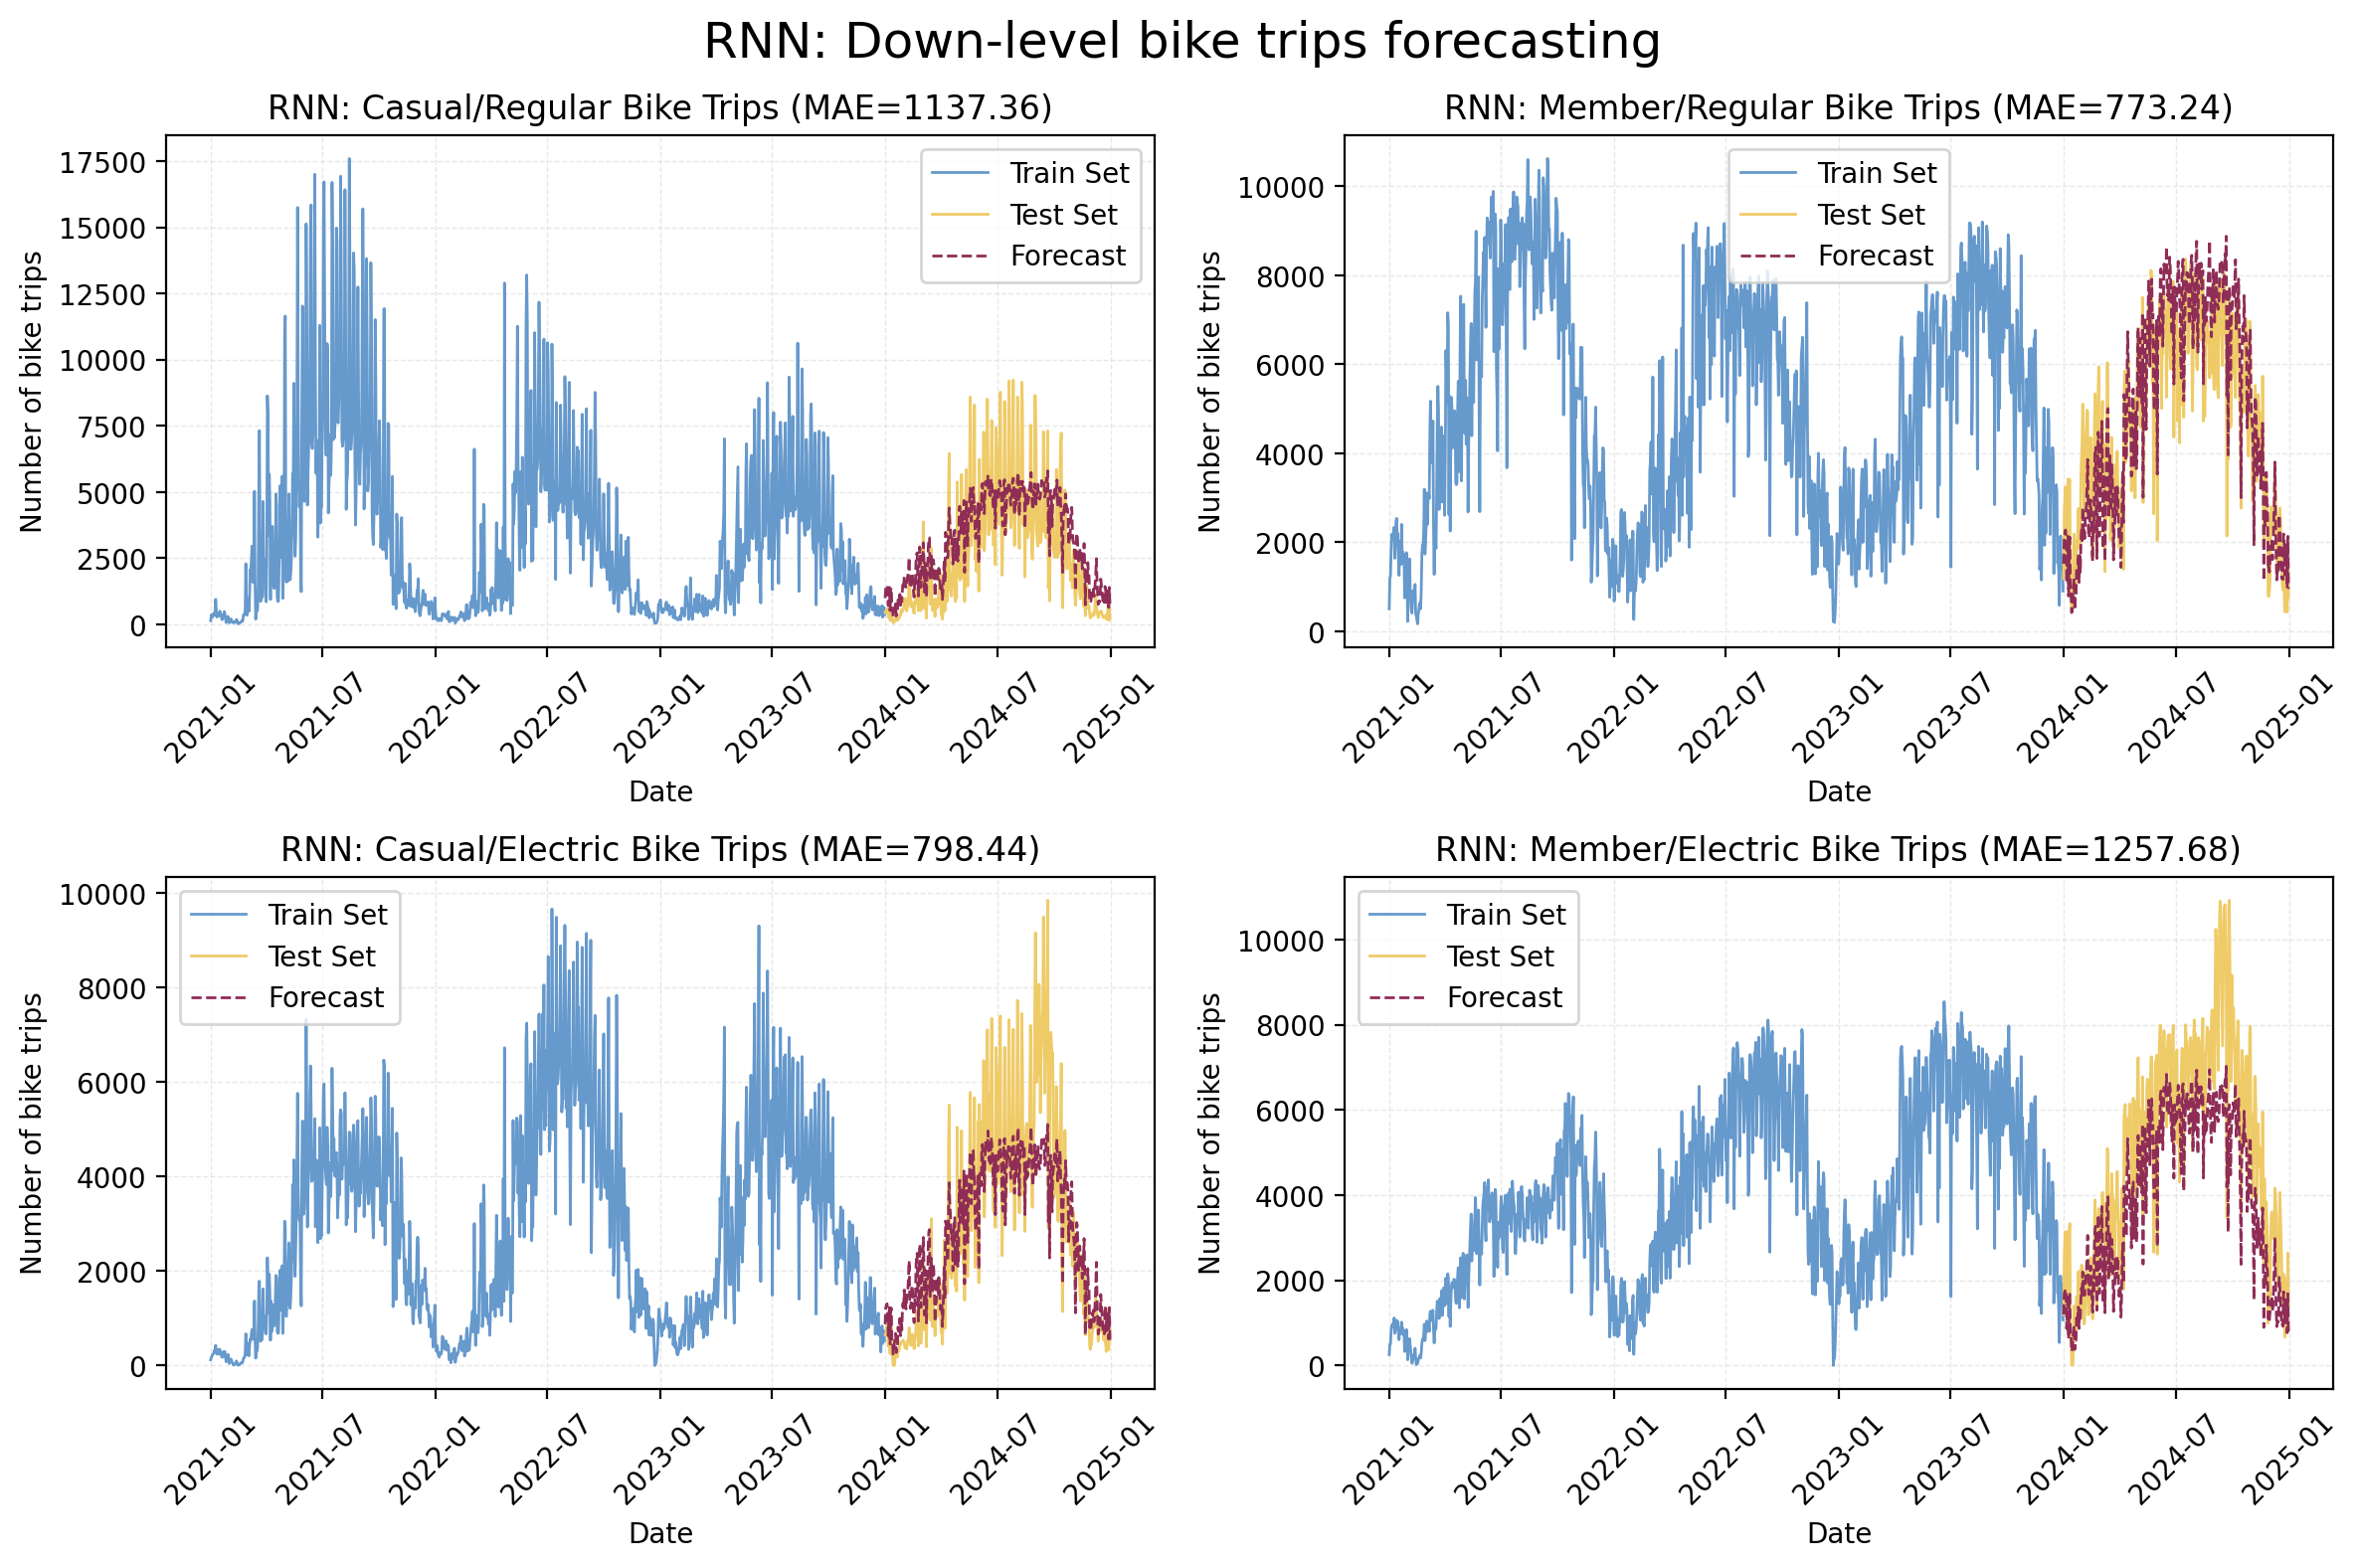

In [49]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')

plot_trips(train=train["casual_regular_bike"], 
                    test=test["casual_regular_bike"],
                    forecast=rnn_td_bottom_forecast["casual_regular_bike"],
                    title=f"RNN: Casual/Regular Bike Trips (MAE={rnn_td_casual_regular_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_regular_bike"], 
                    test=test["member_regular_bike"],
                    forecast=rnn_td_bottom_forecast["member_regular_bike"],
                    title=f"RNN: Member/Regular Bike Trips (MAE={rnn_td_member_regular_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["casual_electric_bike"], 
                    test=test["casual_electric_bike"],
                    forecast=rnn_td_bottom_forecast["casual_electric_bike"],
                    title=f"RNN: Casual/Electric Bike Trips (MAE={rnn_td_casual_electric_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["member_electric_bike"], 
                    test=test["member_electric_bike"],
                    forecast=rnn_td_bottom_forecast["member_electric_bike"],
                    title=f"RNN: Member/Electric Bike Trips (MAE={rnn_td_member_electric_mae:.2f})",
                    ax=ax[1, 1])

plt.suptitle("RNN: Down-level bike trips forecasting", fontsize=18)
plt.tight_layout()
plt.show()

##### Sub-total forecast distribution (button-up for down level)

In [50]:
rnn_td_bu_casual_total_forecast = rnn_td_bottom_forecast["casual_regular_bike"] + \
                                rnn_td_bottom_forecast["casual_electric_bike"]
rnn_td_bu_member_total_forecast = rnn_td_bottom_forecast["member_regular_bike"] + \
                                rnn_td_bottom_forecast["member_electric_bike"]
rnn_td_bu_electric_total_forecast = rnn_td_bottom_forecast["member_electric_bike"] + \
                                  rnn_td_bottom_forecast["casual_electric_bike"]
rnn_td_bu_regular_total_forecast = rnn_td_bottom_forecast["member_regular_bike"] + \
                                 rnn_td_bottom_forecast["casual_regular_bike"]

rnn_td_bu_casual_total_mae = mean_absolute_error(test["casual_total"], rnn_td_bu_casual_total_forecast)
rnn_td_bu_member_total_mae = mean_absolute_error(test["member_total"], rnn_td_bu_member_total_forecast)
rnn_td_bu_electric_total_mae = mean_absolute_error(test["electric_total"], rnn_td_bu_electric_total_forecast)
rnn_td_bu_regular_total_mae = mean_absolute_error(test["regular_total"], rnn_td_bu_regular_total_forecast)

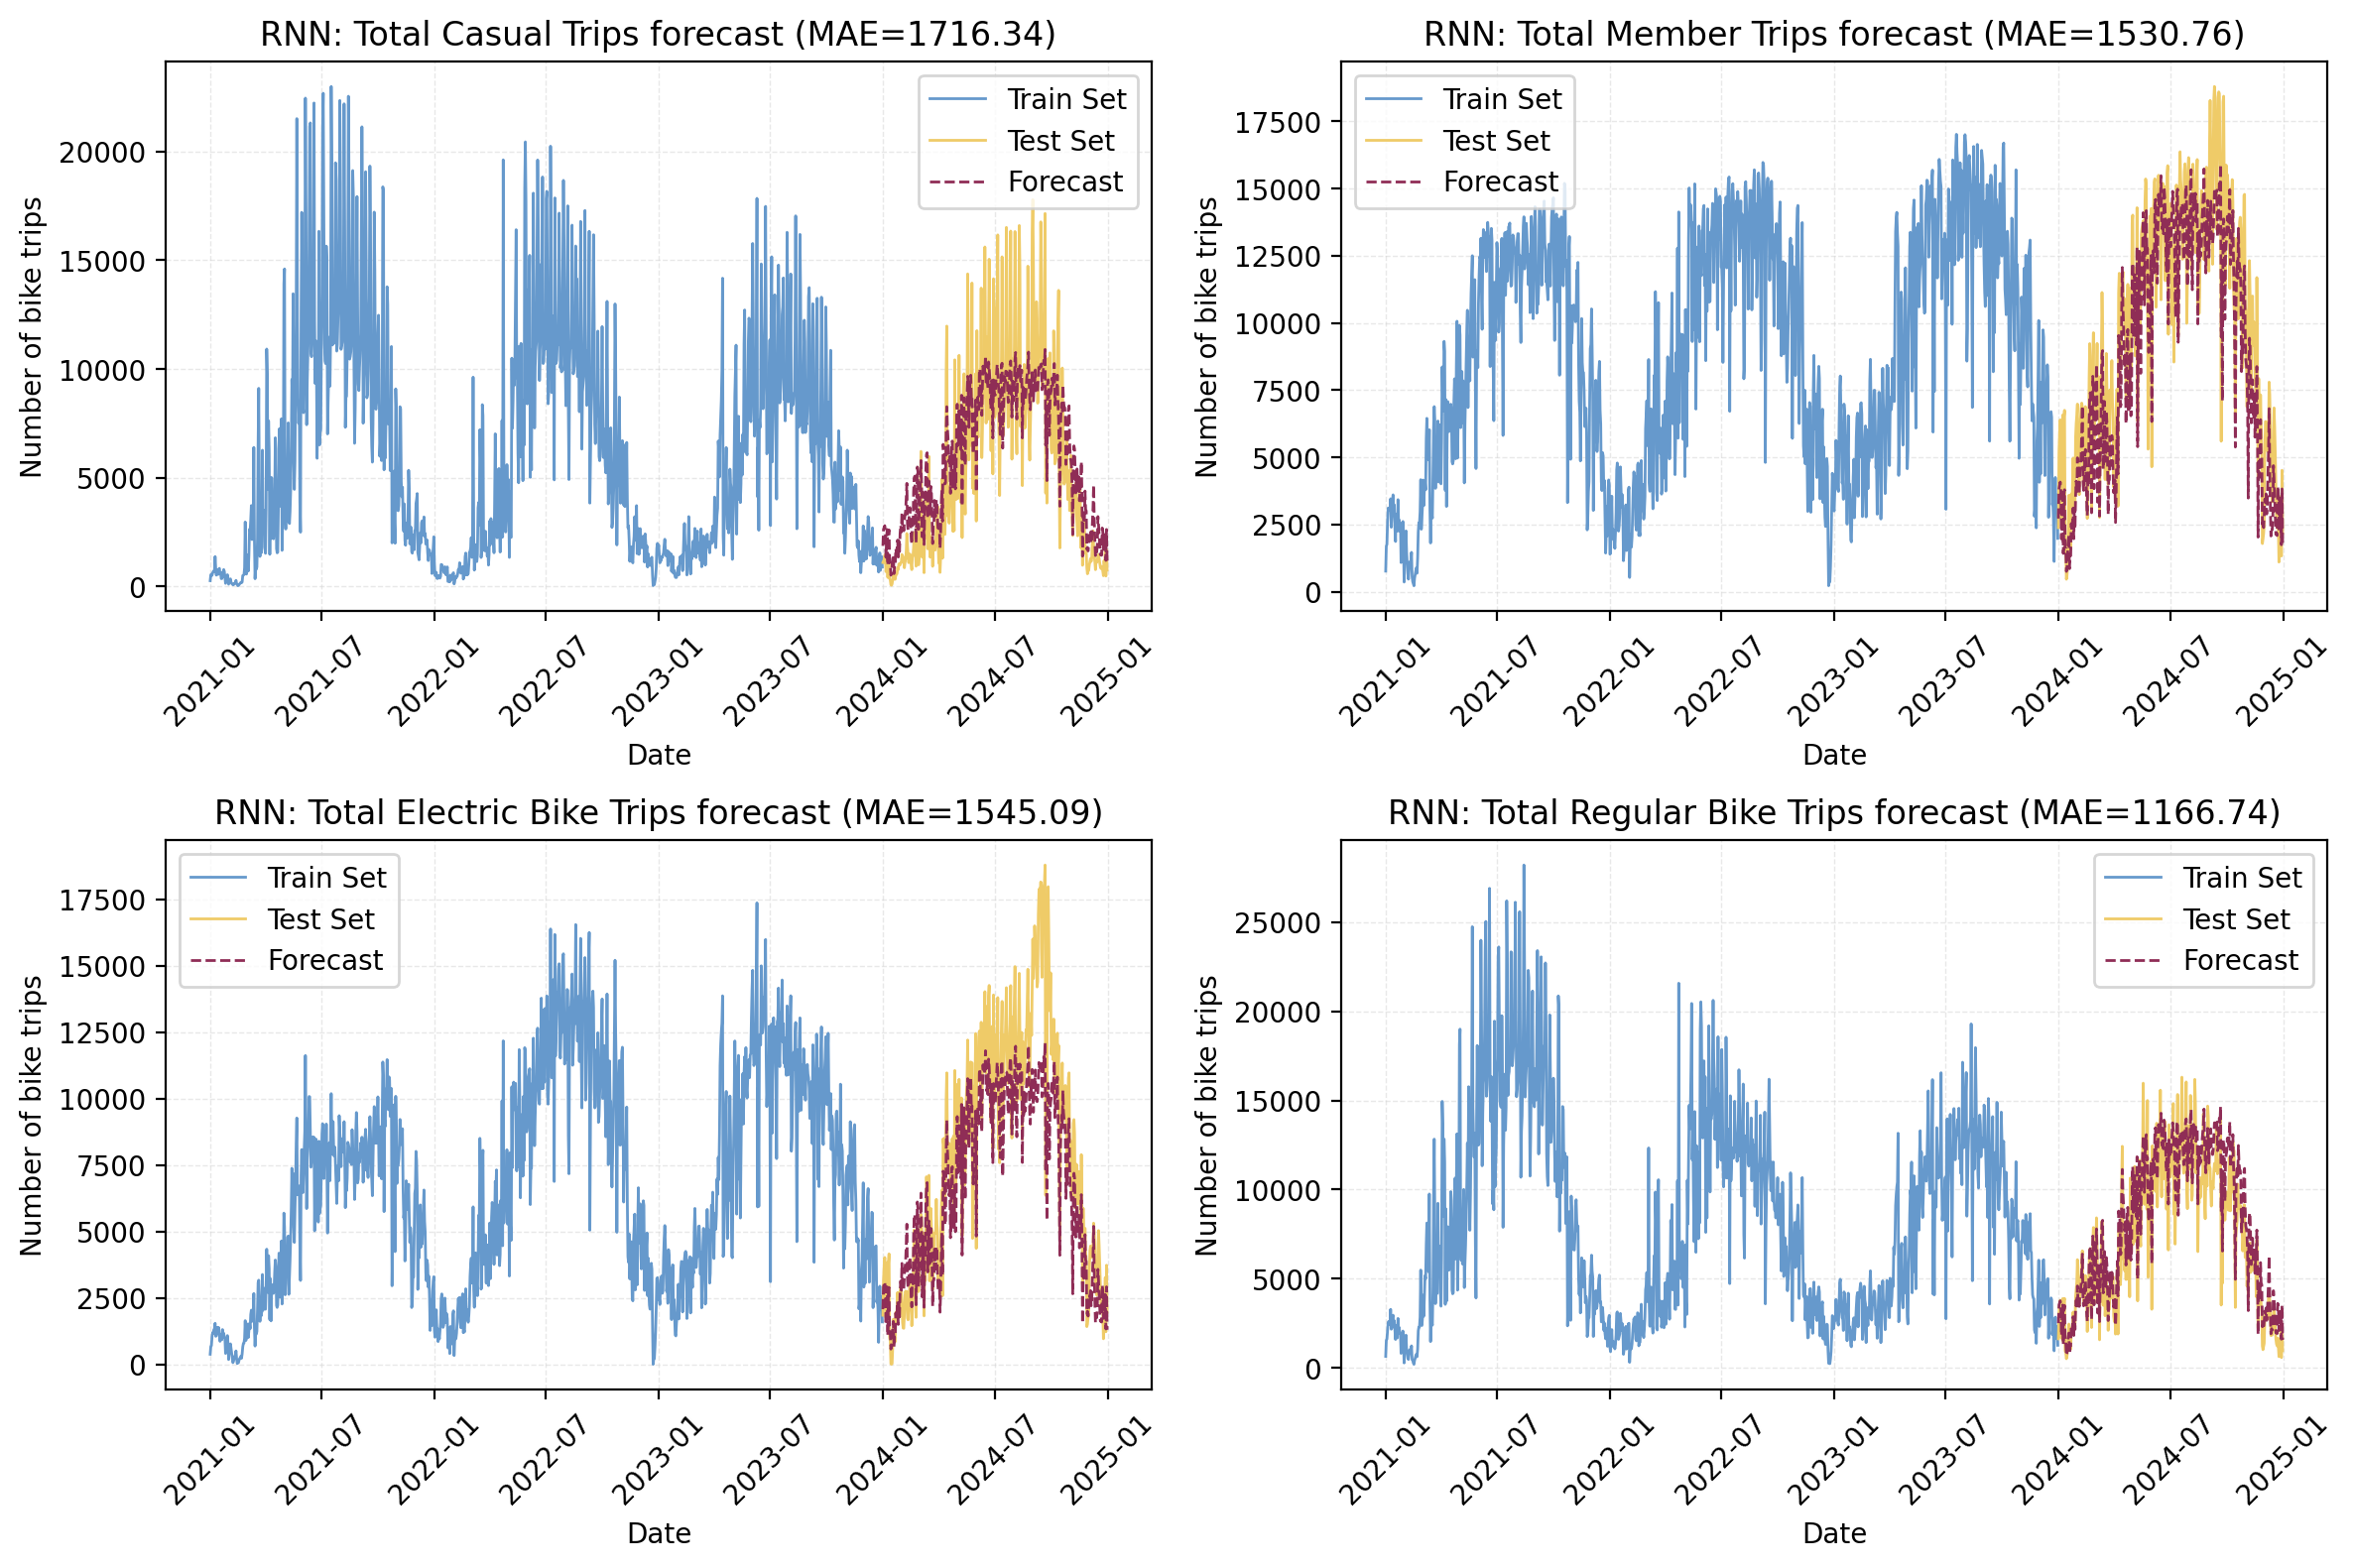

In [51]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

plot_trips(train=train["casual_total"], 
                    test=test["casual_total"],
                    forecast=rnn_td_bu_casual_total_forecast,
                    title=f"RNN: Total Casual Trips forecast (MAE={rnn_td_bu_casual_total_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_total"], 
                    test=test["member_total"],
                    forecast=rnn_td_bu_member_total_forecast,
                    title=f"RNN: Total Member Trips forecast (MAE={rnn_td_bu_member_total_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["electric_total"], 
                    test=test["electric_total"],
                    forecast=rnn_td_bu_electric_total_forecast,
                    title=f"RNN: Total Electric Bike Trips forecast (MAE={rnn_td_bu_electric_total_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["regular_total"], 
                    test=test["regular_total"],
                    forecast=rnn_td_bu_regular_total_forecast,
                    title=f"RNN: Total Regular Bike Trips forecast (MAE={rnn_td_bu_regular_total_mae:.2f})",
                    ax=ax[1, 1])

plt.tight_layout()
plt.show()

In [52]:
rnn_mae_scores['top-down']['mae']['casual_total'] = rnn_td_bu_casual_total_mae
rnn_mae_scores['top-down']['mae']['member_total'] = rnn_td_bu_member_total_mae
rnn_mae_scores['top-down']['mae']['electric_total'] = rnn_td_bu_electric_total_mae
rnn_mae_scores['top-down']['mae']['regular_total'] = rnn_td_bu_regular_total_mae

#### Bottom-Up

##### Casual/Regular

In [54]:
cr_window_size, cr_forecast, cr_results = test_rnn_window_size(train, test, "casual_regular_bike", 
                                                        window_sizes=window_sizes, seeds=SEEDs)

  0%|          | 0/20 [00:00<?, ?it/s]


BEST RNN/LSTM WINDOW SIZE FOR `casual_regular_bike`

-----------------------------------------------------------------
| N. | Random Seed          | Window Size          | MAE        |
-----------------------------------------------------------------
| 1  | 0                    | 30                   | 533.95     |
-----------------------------------------------------------------
| 2  | 0                    | 60                   | 583.16     |
-----------------------------------------------------------------
| 3  | 0                    | 90                   | 533.72     |
-----------------------------------------------------------------
| 4  | 0                    | 120                  | 701.70     |
-----------------------------------------------------------------
| 5  | 42                   | 30                   | 652.68     |
-----------------------------------------------------------------
| 6  | 42                   | 60                   | 534.02     |
----------------------

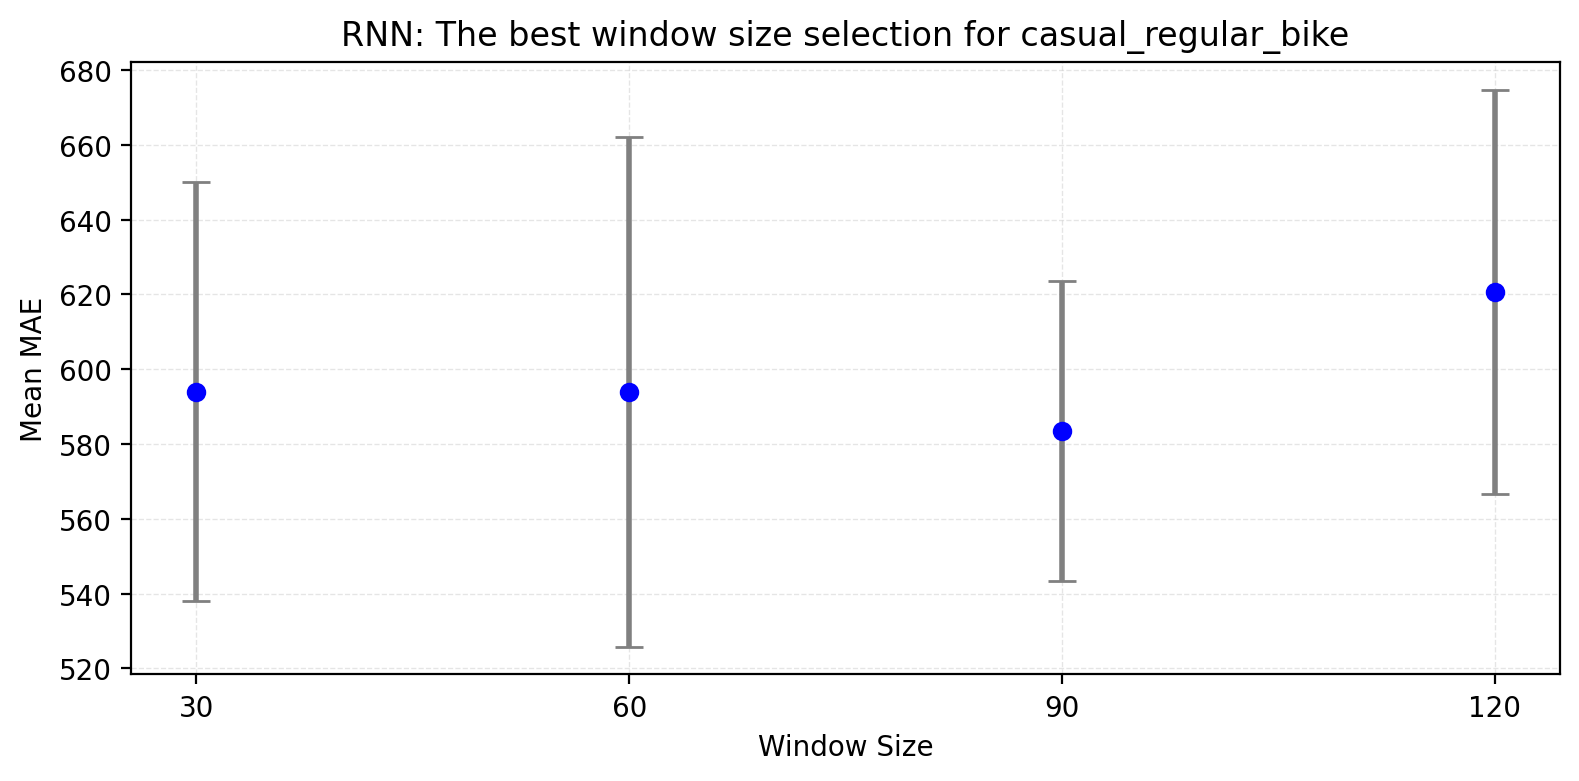

In [68]:
plot_window_size(cr_results, "casual_regular_bike")

In [55]:
# casual/regular forecast
rnn_cr_history, rnn_cr_model, rnn_cr_features, rnn_cr_encoder, rnn_cr_pred = \
            train_validate_rnn(train, test, "casual_regular_bike", H=cr_window_size, verbose=0)

##### Member/Regular

In [56]:
mr_window_size, mr_forecast, mr_results = test_rnn_window_size(train, test, "member_regular_bike", 
                                                        window_sizes=window_sizes, seeds=SEEDs)

  0%|          | 0/20 [00:00<?, ?it/s]


BEST RNN/LSTM WINDOW SIZE FOR `member_regular_bike`

-----------------------------------------------------------------
| N. | Random Seed          | Window Size          | MAE        |
-----------------------------------------------------------------
| 1  | 0                    | 30                   | 478.49     |
-----------------------------------------------------------------
| 2  | 0                    | 60                   | 485.06     |
-----------------------------------------------------------------
| 3  | 0                    | 90                   | 468.68     |
-----------------------------------------------------------------
| 4  | 0                    | 120                  | 493.55     |
-----------------------------------------------------------------
| 5  | 42                   | 30                   | 457.61     |
-----------------------------------------------------------------
| 6  | 42                   | 60                   | 466.72     |
----------------------

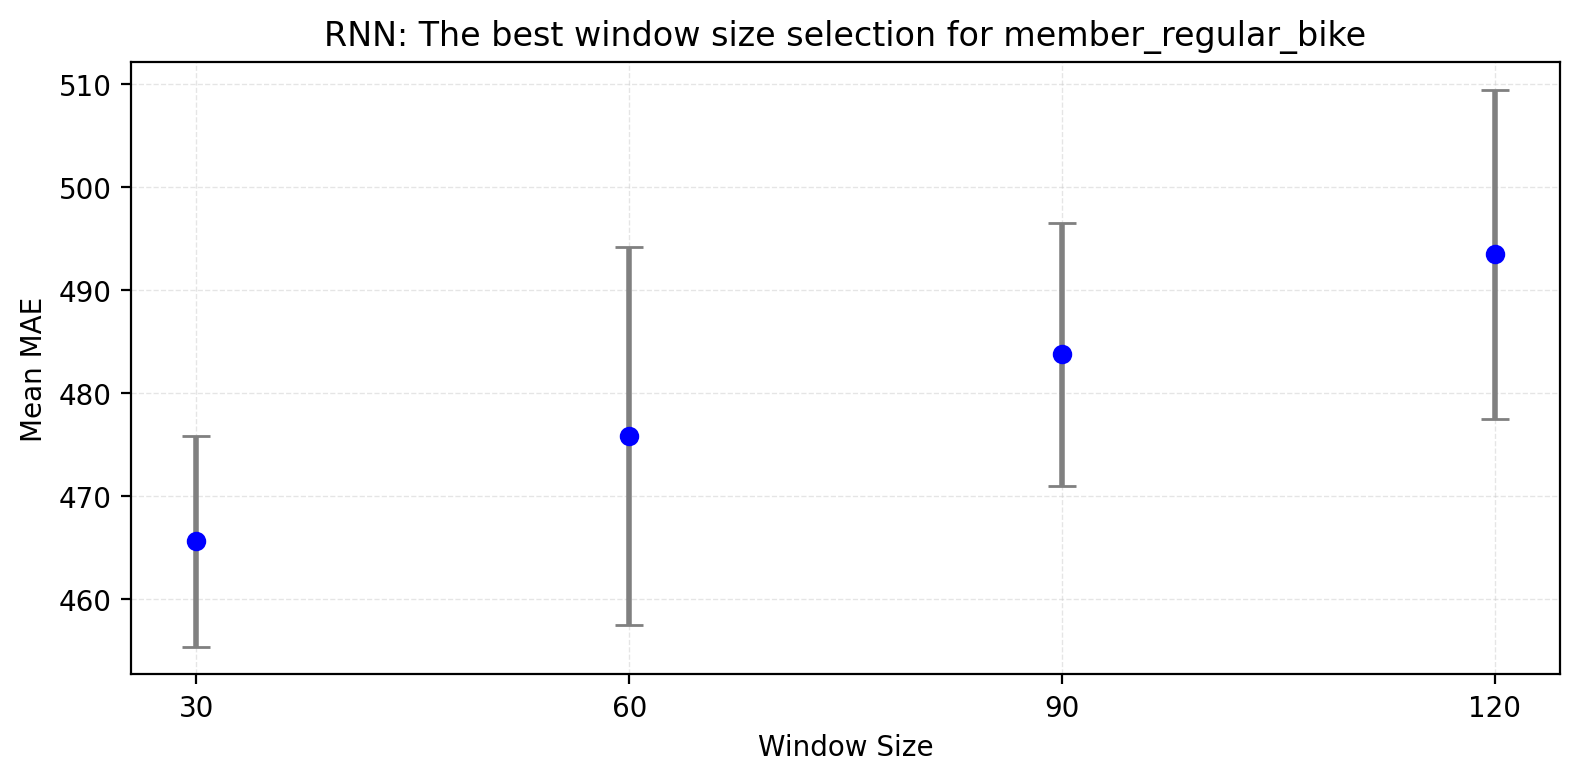

In [69]:
plot_window_size(mr_results, "member_regular_bike")

In [57]:
# member/regular forecast
rnn_mr_history, rnn_mr_model, rnn_mr_features, rnn_mr_encoder, rnn_mr_pred = \
            train_validate_rnn(train, test, "member_regular_bike", H=mr_window_size, verbose=0)

##### Casual/Electric

In [58]:
ce_window_size, ce_forecast, ce_results = test_rnn_window_size(train, test, "casual_electric_bike", 
                                                        window_sizes=window_sizes, seeds=SEEDs)

  0%|          | 0/20 [00:00<?, ?it/s]


BEST RNN/LSTM WINDOW SIZE FOR `casual_electric_bike`

-----------------------------------------------------------------
| N. | Random Seed          | Window Size          | MAE        |
-----------------------------------------------------------------
| 1  | 0                    | 30                   | 505.44     |
-----------------------------------------------------------------
| 2  | 0                    | 60                   | 568.36     |
-----------------------------------------------------------------
| 3  | 0                    | 90                   | 502.79     |
-----------------------------------------------------------------
| 4  | 0                    | 120                  | 523.25     |
-----------------------------------------------------------------
| 5  | 42                   | 30                   | 524.63     |
-----------------------------------------------------------------
| 6  | 42                   | 60                   | 490.46     |
---------------------

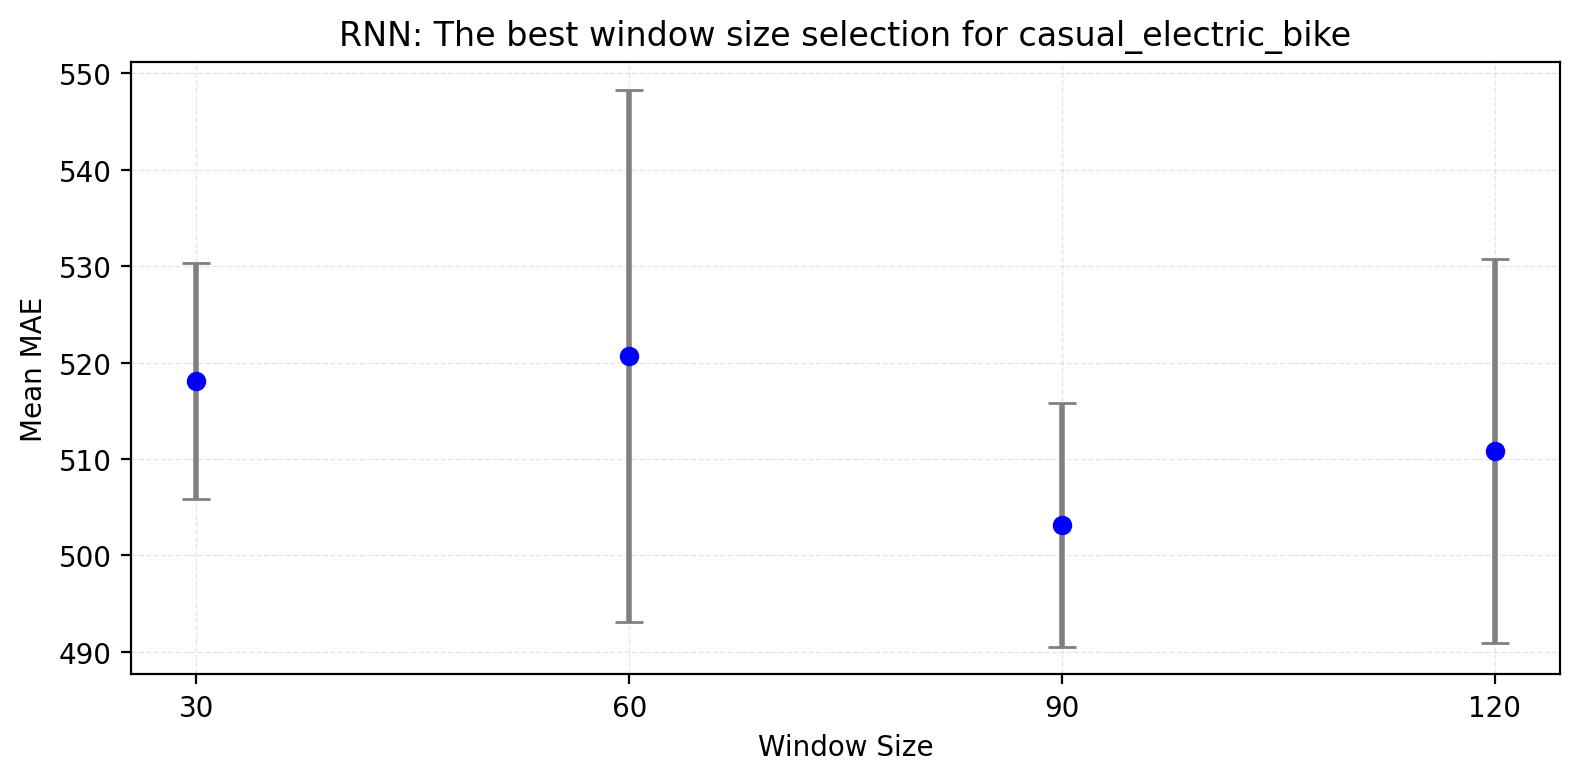

In [70]:
plot_window_size(ce_results, "casual_electric_bike")

In [59]:
# casual/electric forecast
rnn_ce_history, rnn_ce_model, rnn_ce_features, rnn_ce_encoder, rnn_ce_pred = \
            train_validate_rnn(train, test, "casual_electric_bike", H=ce_window_size, verbose=0)

##### Member/Electric

In [60]:
me_window_size, me_forecast, me_results = test_rnn_window_size(train, test, "member_electric_bike", 
                                                        window_sizes=window_sizes, seeds=SEEDs)

  0%|          | 0/20 [00:00<?, ?it/s]


BEST RNN/LSTM WINDOW SIZE FOR `member_electric_bike`

-----------------------------------------------------------------
| N. | Random Seed          | Window Size          | MAE        |
-----------------------------------------------------------------
| 1  | 0                    | 30                   | 515.29     |
-----------------------------------------------------------------
| 2  | 0                    | 60                   | 517.90     |
-----------------------------------------------------------------
| 3  | 0                    | 90                   | 517.01     |
-----------------------------------------------------------------
| 4  | 0                    | 120                  | 541.27     |
-----------------------------------------------------------------
| 5  | 42                   | 30                   | 580.66     |
-----------------------------------------------------------------
| 6  | 42                   | 60                   | 555.84     |
---------------------

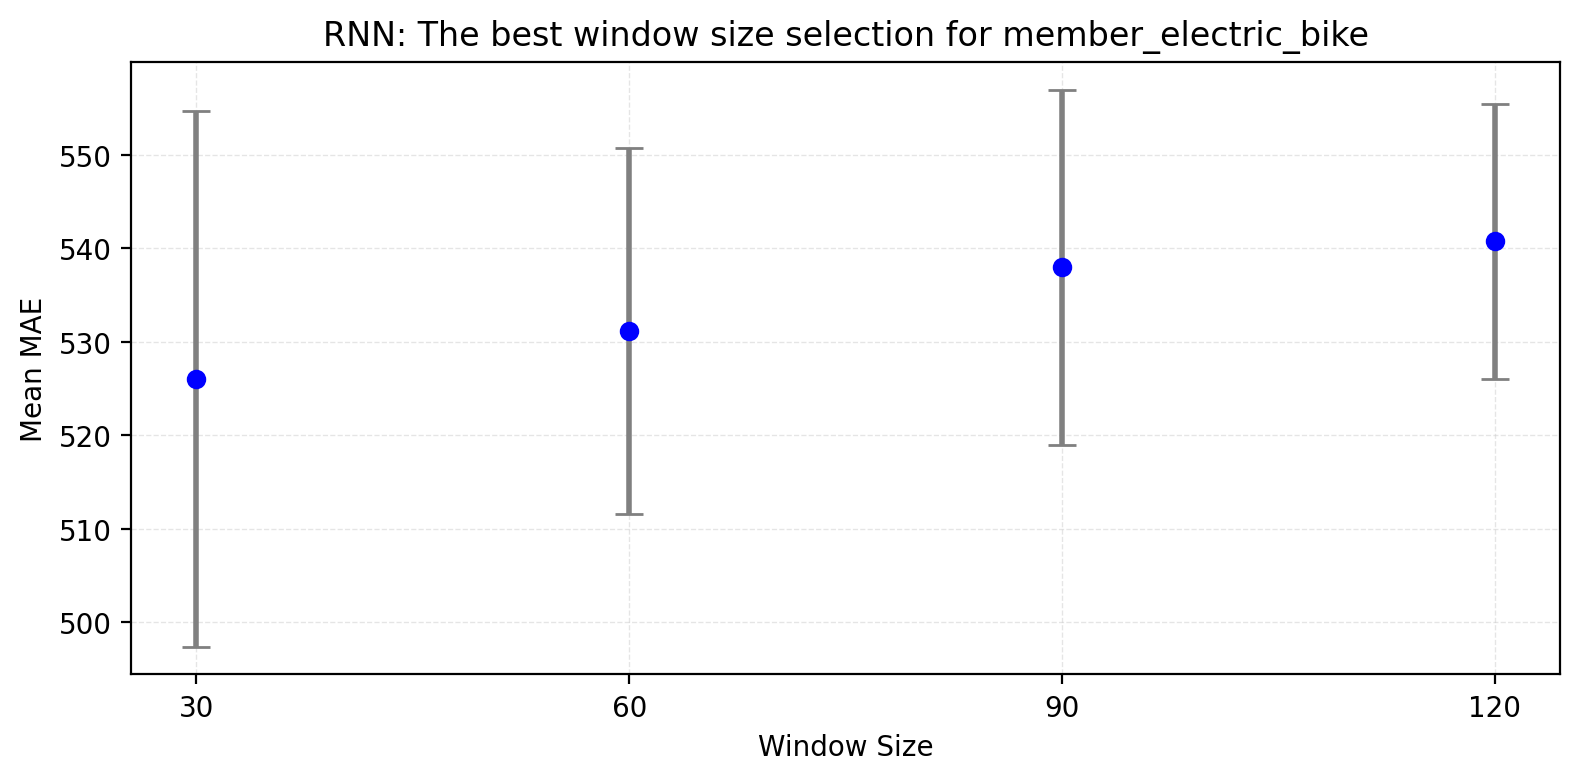

In [71]:
plot_window_size(me_results, "member_electric_bike")

In [61]:
# member/electric forecast
rnn_me_history, rnn_me_model, rnn_cr_features, rnn_me_encoder, rnn_me_pred = \
            train_validate_rnn(train, test, "member_electric_bike", H=me_window_size, verbose=0)

In [72]:
rnn_cr_mae = mean_absolute_error(test["casual_regular_bike"], rnn_cr_pred)
rnn_mr_mae = mean_absolute_error(test["member_regular_bike"], rnn_mr_pred)
rnn_ce_mae = mean_absolute_error(test["casual_electric_bike"], rnn_ce_pred)
rnn_me_mae = mean_absolute_error(test["member_electric_bike"], rnn_me_pred)

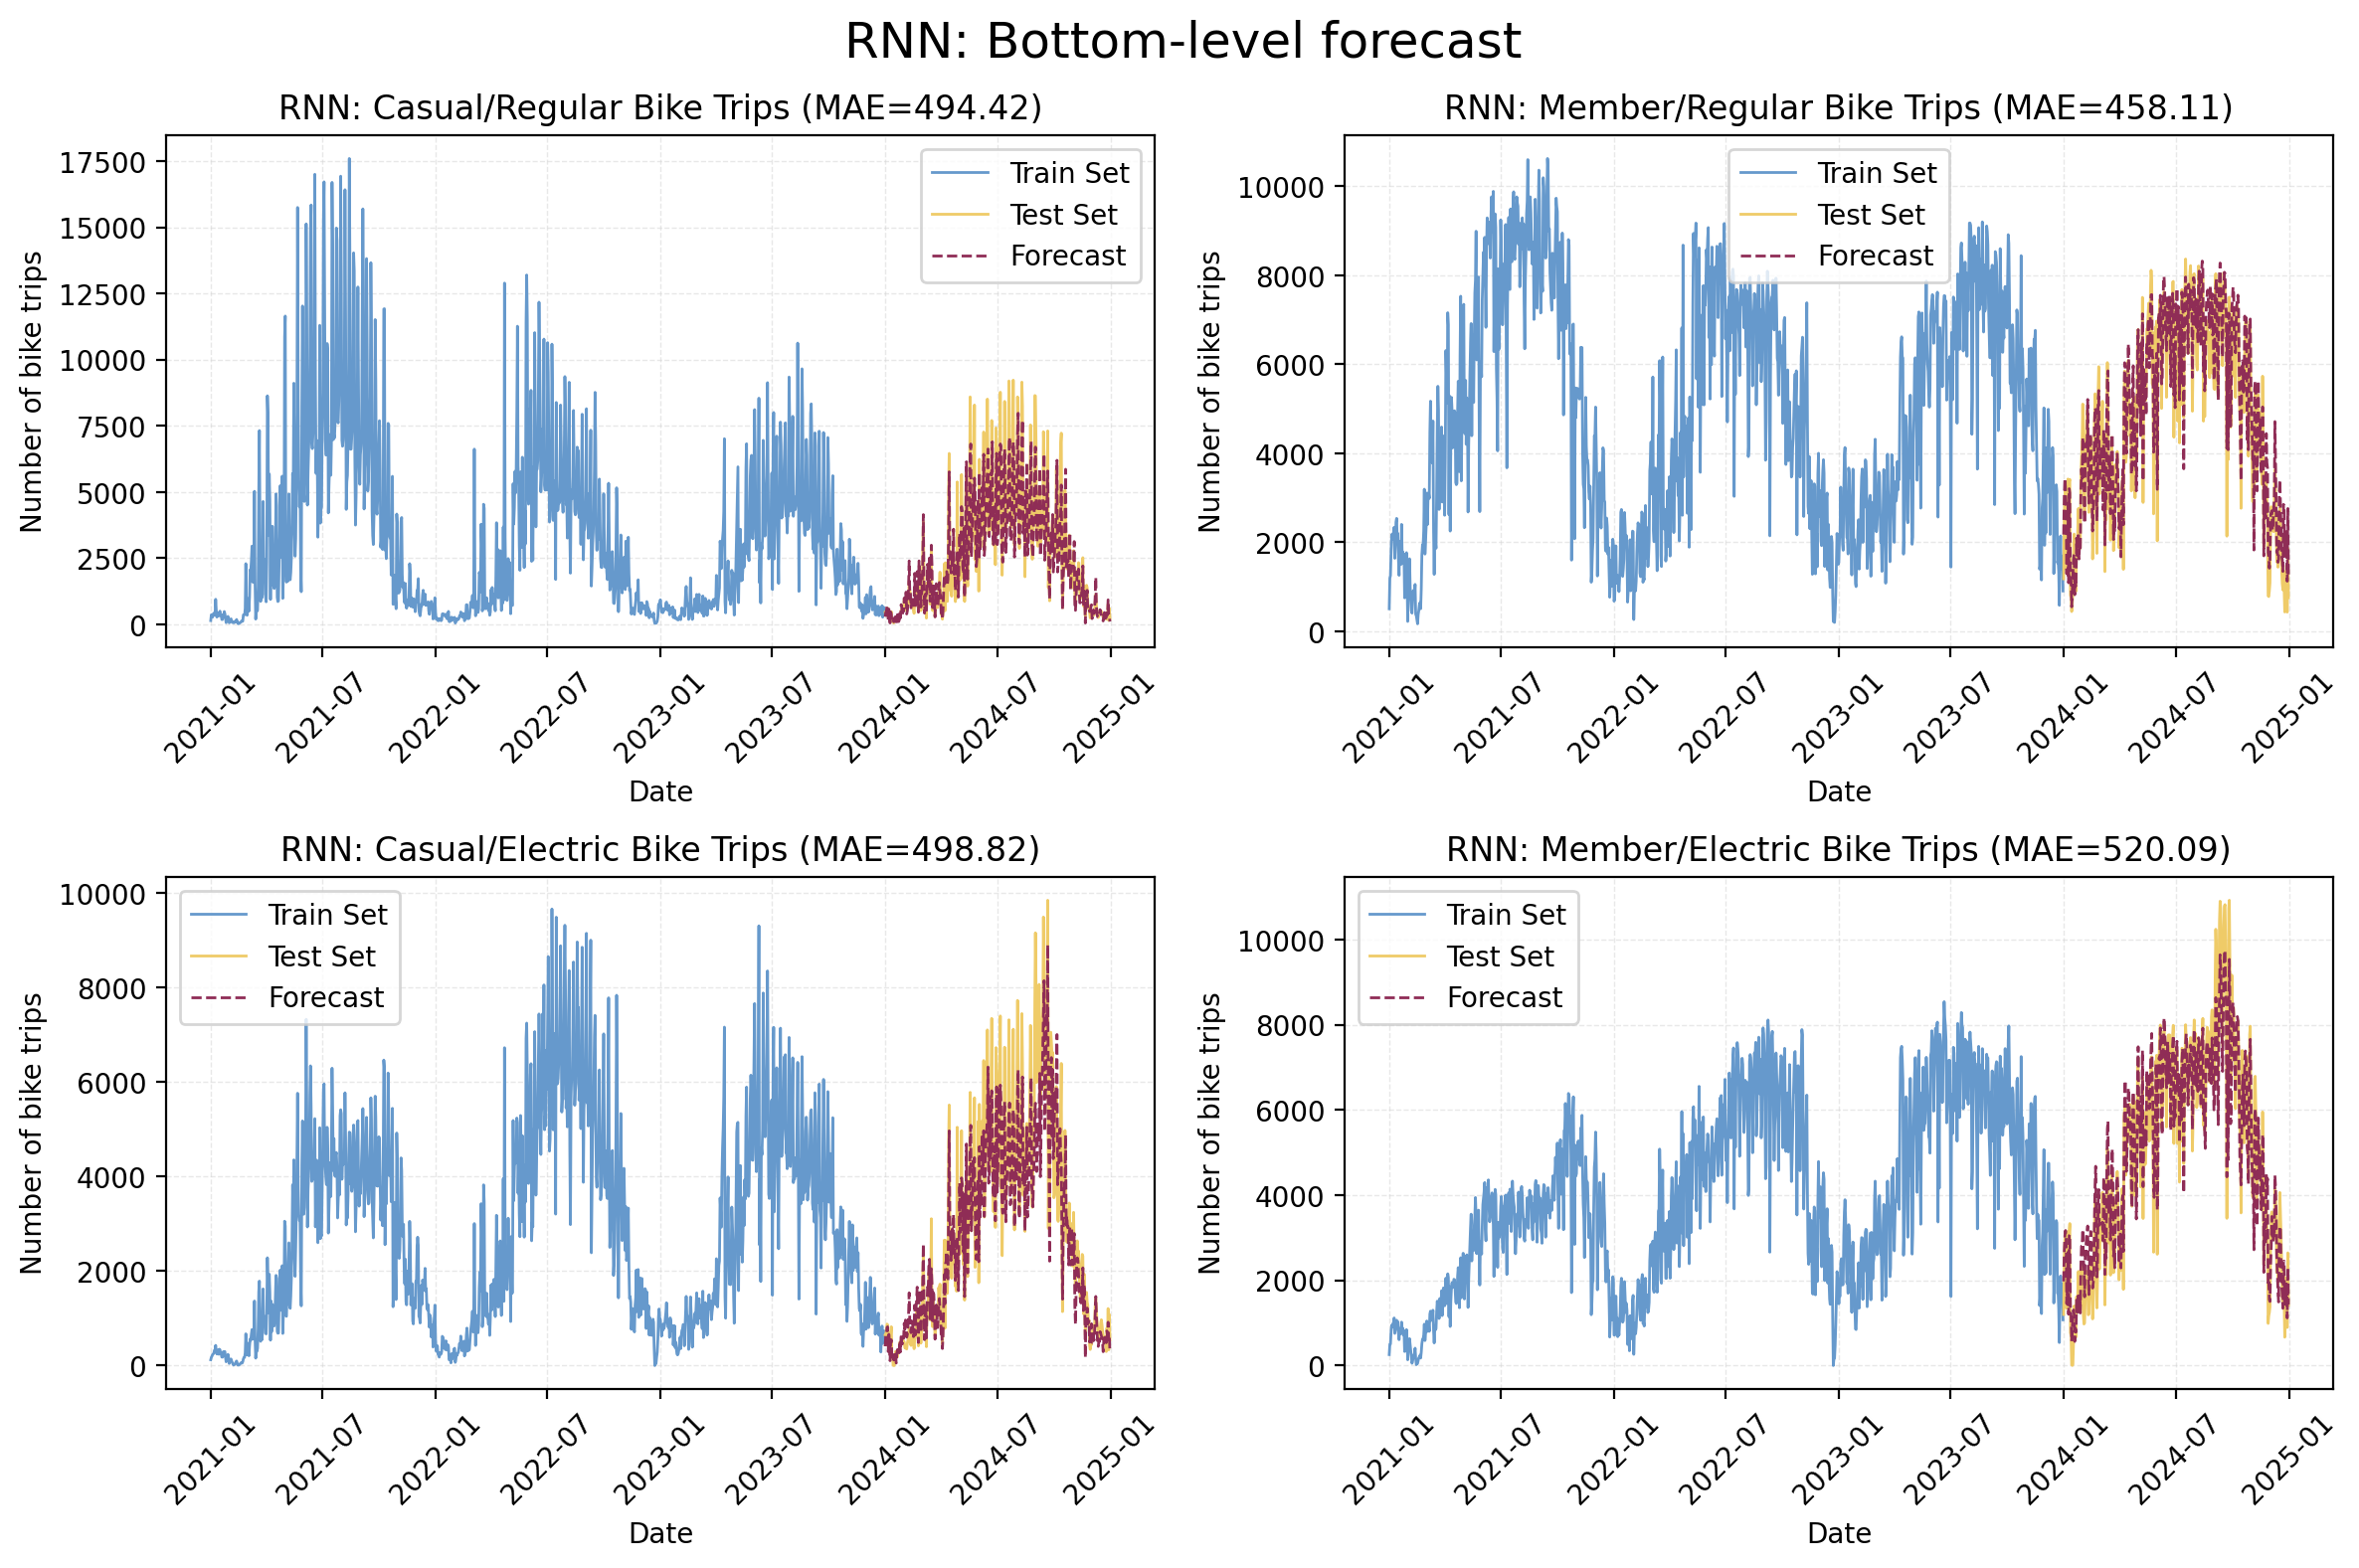

In [73]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')

plot_trips(train=train["casual_regular_bike"], 
                    test=test["casual_regular_bike"],
                    forecast=pd.DataFrame(rnn_cr_pred, index=test.index),
                    title=f"RNN: Casual/Regular Bike Trips (MAE={rnn_cr_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_regular_bike"], 
                    test=test["member_regular_bike"],
                    forecast=pd.DataFrame(rnn_mr_pred, index=test.index),
                    title=f"RNN: Member/Regular Bike Trips (MAE={rnn_mr_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["casual_electric_bike"], 
                    test=test["casual_electric_bike"],
                    forecast=pd.DataFrame(rnn_ce_pred, index=test.index),
                    title=f"RNN: Casual/Electric Bike Trips (MAE={rnn_ce_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["member_electric_bike"], 
                    test=test["member_electric_bike"],
                    forecast=pd.DataFrame(rnn_me_pred, index=test.index),
                    title=f"RNN: Member/Electric Bike Trips (MAE={rnn_me_mae:.2f})",
                    ax=ax[1, 1])

plt.suptitle("RNN: Bottom-level forecast", fontsize=18)
plt.tight_layout()
plt.show()

In [74]:
rnn_mae_scores['bottom-up']['mae']['casual_regular_bike'] = rnn_cr_mae
rnn_mae_scores['bottom-up']['mae']['member_regular_bike'] = rnn_mr_mae
rnn_mae_scores['bottom-up']['mae']['casual_electric_bike'] = rnn_ce_mae
rnn_mae_scores['bottom-up']['mae']['member_electric_bike'] = rnn_me_mae

##### Sub-Total forecasting (Bottom-Up)

In [75]:
rnn_bu_casual_total_forecast = rnn_cr_pred + rnn_ce_pred
rnn_bu_member_total_forecast = rnn_mr_pred + rnn_me_pred
rnn_bu_electric_total_forecast = rnn_me_pred + rnn_ce_pred
rnn_bu_regular_total_forecast = rnn_cr_pred + rnn_mr_pred

rnn_bu_casual_total_mae = mean_absolute_error(test['casual_total'], rnn_bu_casual_total_forecast)
rnn_bu_member_total_mae = mean_absolute_error(test['member_total'], rnn_bu_member_total_forecast)
rnn_bu_electric_total_mae = mean_absolute_error(test['electric_total'], rnn_bu_electric_total_forecast)
rnn_bu_regular_total_mae = mean_absolute_error(test['regular_total'], rnn_bu_regular_total_forecast)

In [76]:
rnn_mae_scores['bottom-up']['mae']['casual_total'] = rnn_bu_casual_total_mae
rnn_mae_scores['bottom-up']['mae']['member_total'] = rnn_bu_member_total_mae
rnn_mae_scores['bottom-up']['mae']['electric_total'] = rnn_bu_electric_total_mae
rnn_mae_scores['bottom-up']['mae']['regular_total'] = rnn_bu_regular_total_mae

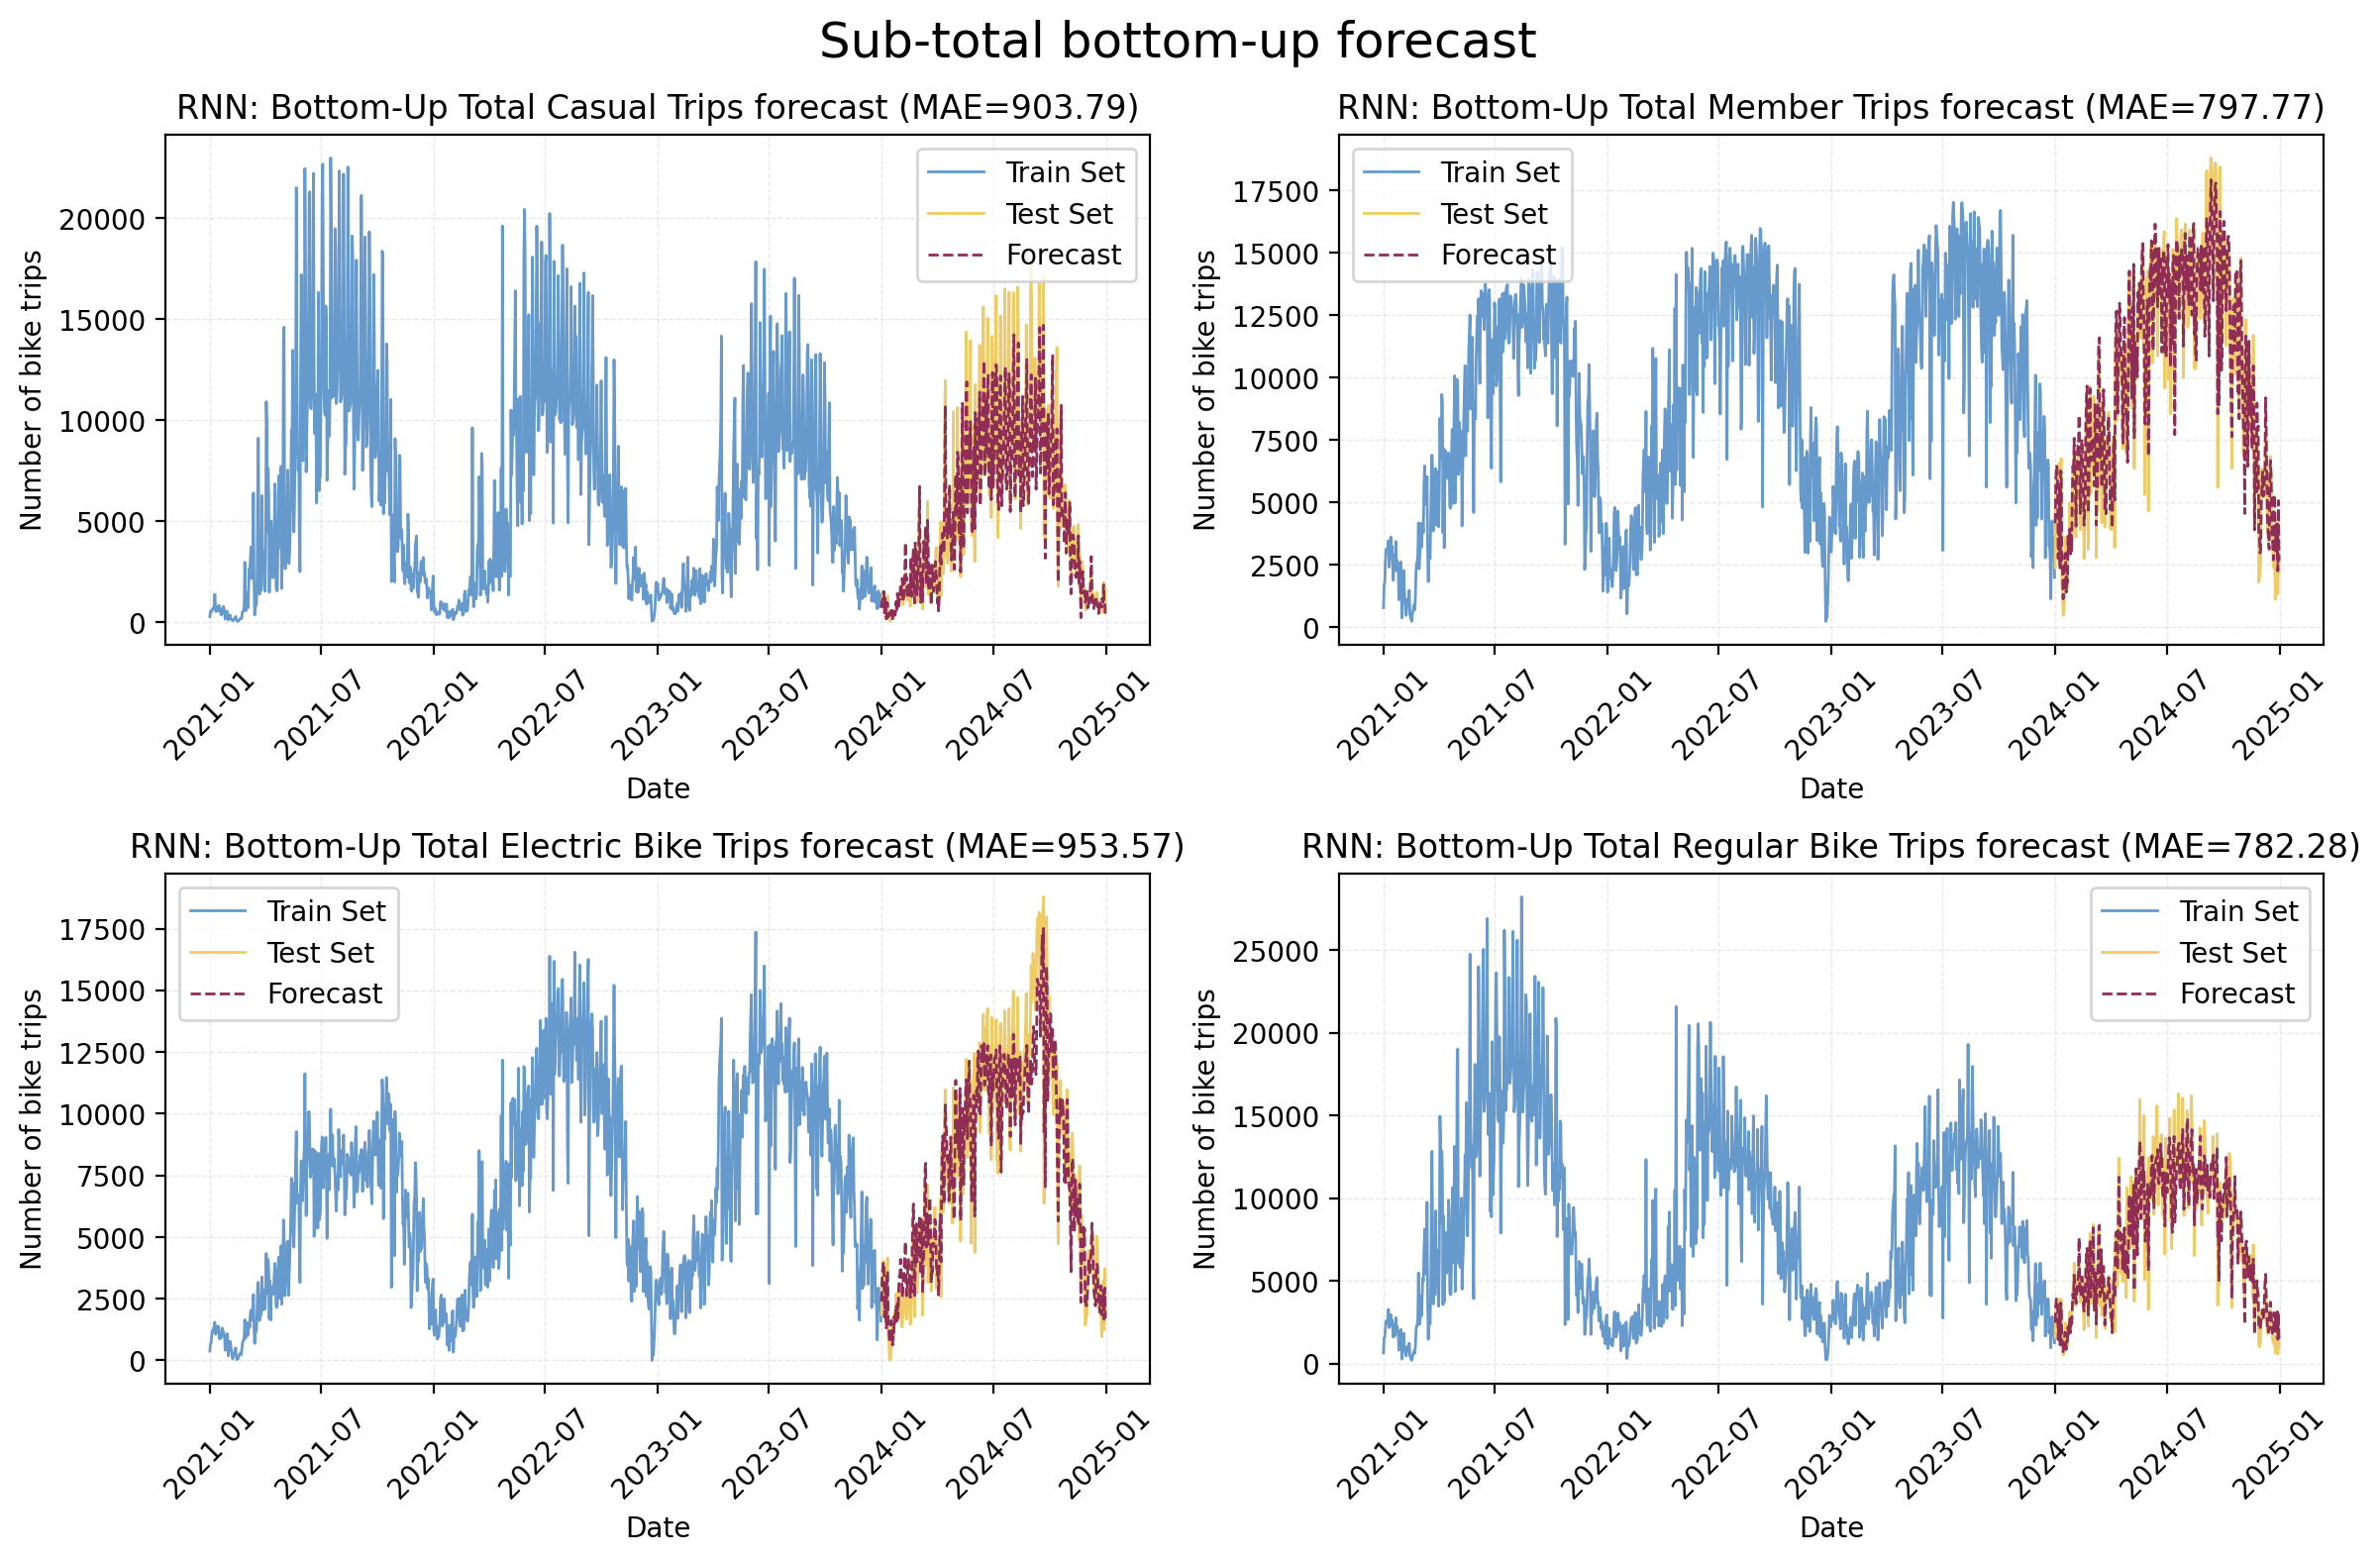

In [77]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

plot_trips(train=train["casual_total"], 
                    test=test["casual_total"],
                    forecast=pd.DataFrame(rnn_bu_casual_total_forecast, test.index),
                    title=f"RNN: Bottom-Up Total Casual Trips forecast (MAE={rnn_bu_casual_total_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_total"], 
                    test=test["member_total"],
                    forecast=pd.DataFrame(rnn_bu_member_total_forecast, test.index),
                    title=f"RNN: Bottom-Up Total Member Trips forecast (MAE={rnn_bu_member_total_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["electric_total"], 
                    test=test["electric_total"],
                    forecast=pd.DataFrame(rnn_bu_electric_total_forecast, test.index),
                    title=f"RNN: Bottom-Up Total Electric Bike Trips forecast (MAE={rnn_bu_electric_total_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["regular_total"], 
                    test=test["regular_total"],
                    forecast=pd.DataFrame(rnn_bu_regular_total_forecast, test.index),
                    title=f"RNN: Bottom-Up Total Regular Bike Trips forecast (MAE={rnn_bu_regular_total_mae:.2f})",
                    ax=ax[1, 1])

plt.suptitle("Sub-total bottom-up forecast", fontsize=18)
plt.tight_layout()
plt.show()

##### Total forecaasting (Bottom-Up)

In [78]:
rnn_bu_total_forecast = rnn_cr_pred + \
                     rnn_ce_pred + \
                        rnn_me_pred + \
                            rnn_mr_pred

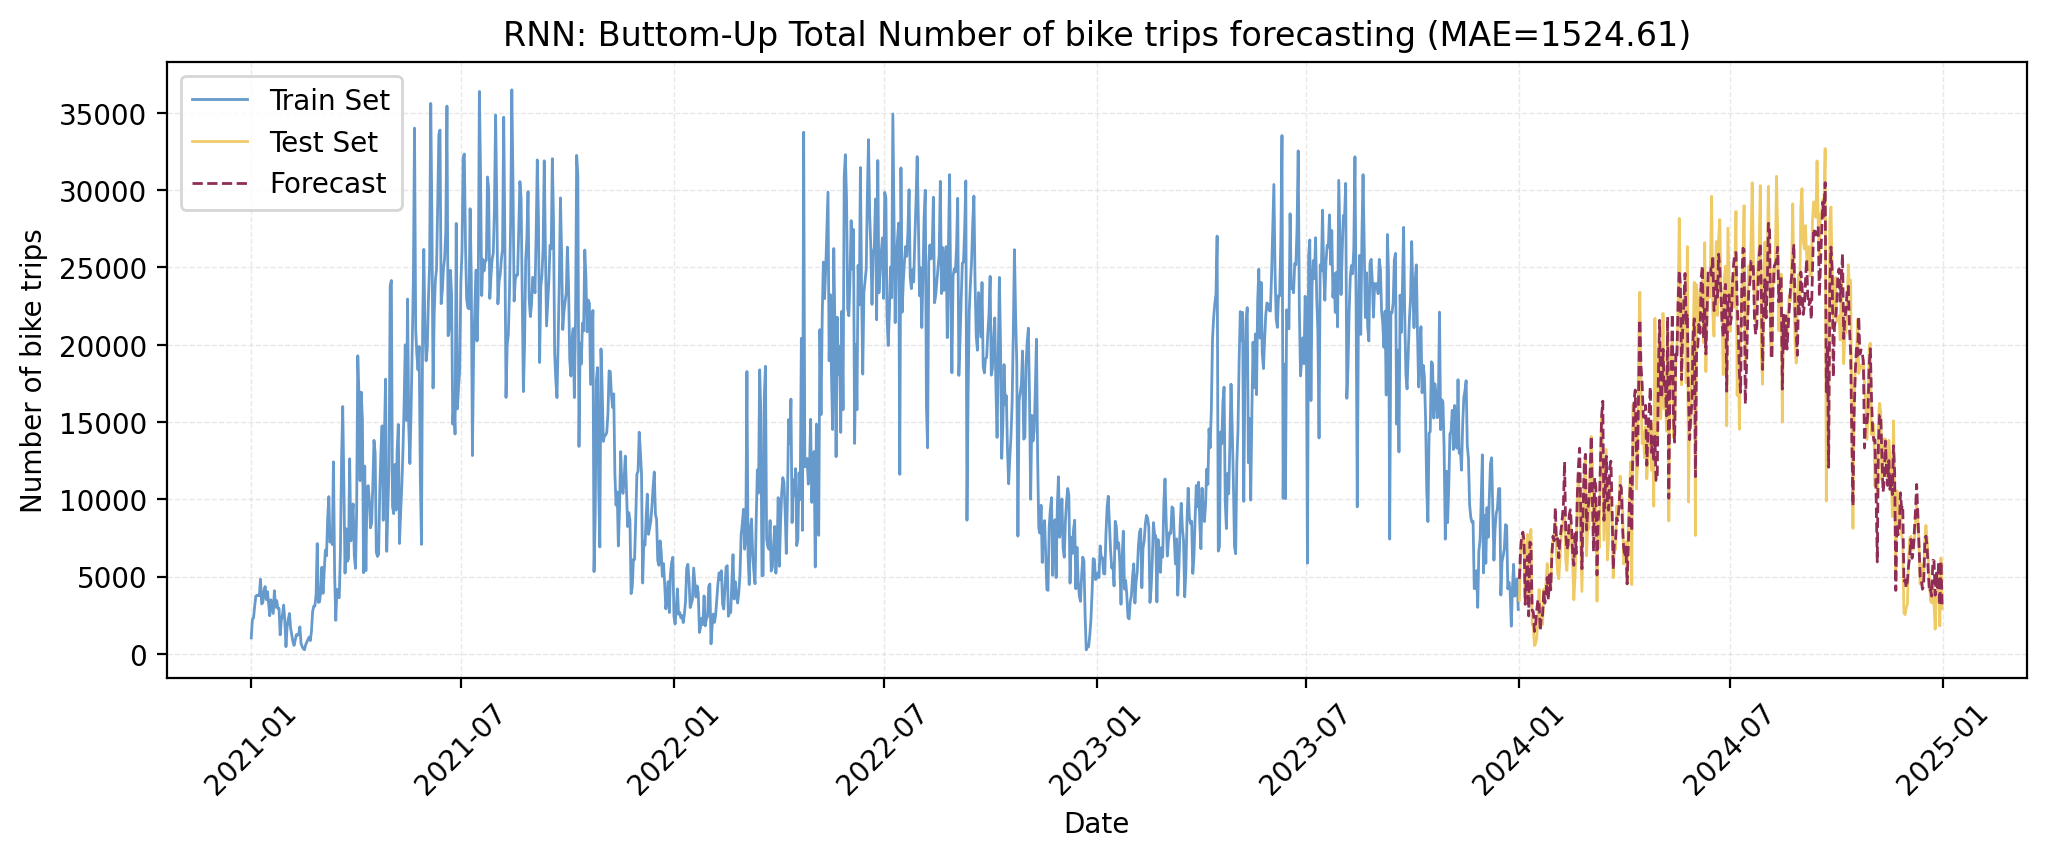

In [79]:
rnn_bu_total_mae = mean_absolute_error(test["total_rides"], rnn_bu_total_forecast)

# Viz the forecast
_, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_trips(ax, train["total_rides"], test["total_rides"], 
           forecast=pd.DataFrame(rnn_bu_total_forecast, index=test.index),
           title=f"RNN: Buttom-Up Total Number of bike trips forecasting (MAE={rnn_bu_total_mae:.2f})")

plt.show()

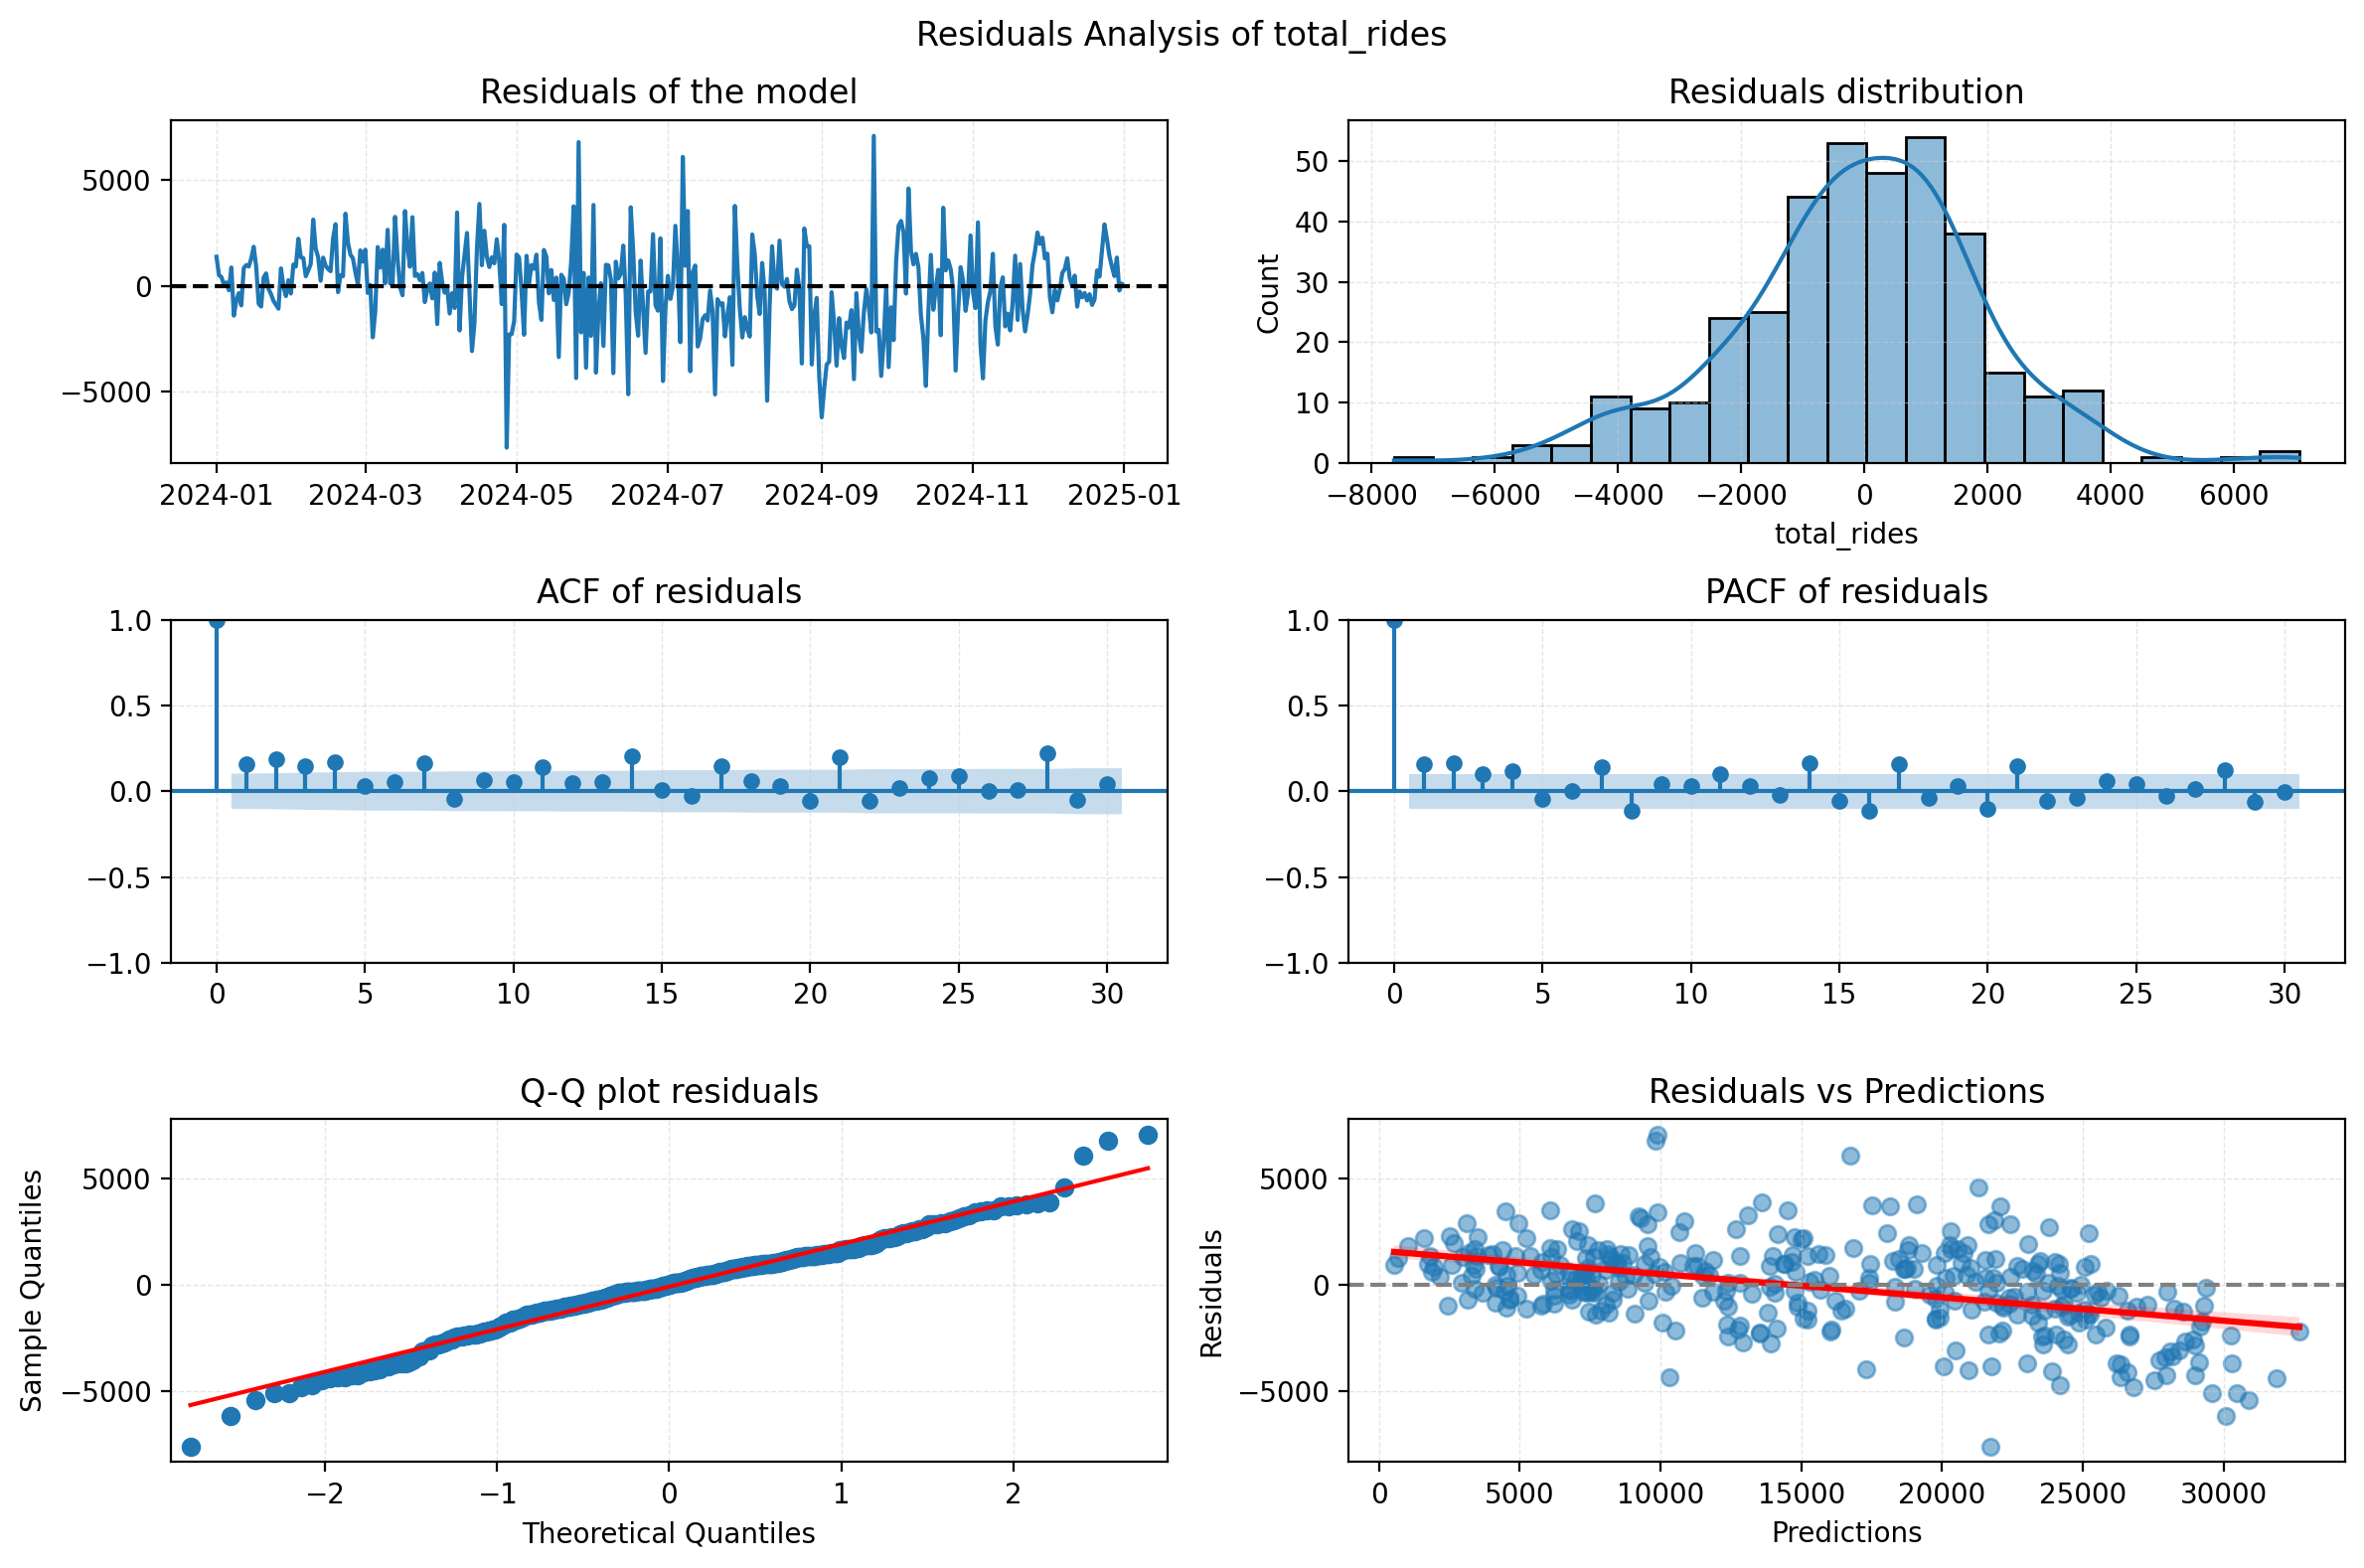


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  56.1306     0.0000
Residuals are autocorrelated

-- Dickey–Fuller test --
ADF Statistic: -3.012976405036734
p-value: 0.033700209600222894
Time series is stationary

-- KPSS test --
ADF Statistic: 0.25898997246258265
p-value: 0.01
Time series is non stationary


/Users/dmitry_luchkin/Documents/00_My_Documents/01_Projects/02_Doing/XX_Divvy_bike_sharing_forecast/01_notebooks/../02_scripts/utils/plotting/viz.py:231: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(residuals, regression='ct')


In [80]:
check_residuals(rnn_bu_total_forecast, test["total_rides"], "total_rides")

In [81]:
rnn_mae_scores['bottom-up']['mae']['total_rides'] = rnn_bu_total_mae

In [82]:
rnn_mae_scores_df = pd.DataFrame({method: values['mae'] for method, values in rnn_mae_scores.items()})
rnn_mae_scores_df.index.name= "MAE"

rnn_mae_scores_df

,bottom-up,top-down
MAE,,
total_rides,"1,524.6052","1,677.7610"
regular_total,782.2802,"1,166.7409"
electric_total,953.5711,"1,545.0898"
casual_total,903.7900,"1,716.3392"
member_total,797.7675,"1,530.7576"
casual_regular_bike,494.4156,"1,137.3634"
member_regular_bike,458.1068,773.2396
casual_electric_bike,498.8242,798.4394
member_electric_bike,520.0868,"1,257.6827"


### Save results <a name='save-data'></a>

In [83]:
"""
Dump Structure

{
    # Bottom-level entry
    "target_name": {
        "level": "bottom",
        "window_size": int,                # Window size
        "forecast": np.ndarray
    },

    # Cross-level or Top-level
    "target_name": {
        "level": "cross|top",
        "sum": [...],                      # Bottom-level keys to sum forecasts from
        "forecast": np.ndarray             # Pre-aggregated forecast
    }
}


"""
rnn_models_dump = {
    "rnn":{
        # bottom-level
        "casual_regular_bike": {
            "level": "bottom",
            "window_size": cr_window_size,
            "forecast": rnn_cr_pred
        },
        "casual_electric_bike": {
            "level": "bottom",
            "window_size": ce_window_size,
            "forecast": rnn_ce_pred
        },
        "member_regular_bike": {
            "level": "bottom",
            "window_size": mr_window_size,
            "forecast": rnn_mr_pred
        },
        "member_electric_bike": {
            "level": "bottom",
            "window_size": me_window_size,
            "forecast": rnn_me_pred
        },
        # cross level
        "casual_total":{
            "level": "cross",
            "sum": ["casual_regular_bike", "casual_electric_bike"],
            "forecast": rnn_bu_casual_total_forecast
        },
        "member_total":{
            "level": "cross",
            "sum": ["member_regular_bike", "member_electric_bike"],
            "forecast": rnn_bu_member_total_forecast
        },
        "electric_total":{
            "level": "cross",
            "sum": ["member_electric_bike", "casual_electric_bike"],
            "forecast": rnn_bu_electric_total_forecast
        },
        "regular_total":{
            "level": "cross",
            "sum": ["member_regular_bike", "casual_regular_bike"],
            "forecast": rnn_bu_regular_total_forecast
        },
        # top-level
        "total":{
            "level": "top",
            "sum": ["member_regular_bike", "casual_regular_bike", "member_electric_bike", "casual_electric_bike"],
            "forecast": rnn_bu_total_forecast
        },
    }
}

In [84]:
dirname = "../03_models/02_rnn/"
with open(dirname + "rnn_models_dump.pkl", "wb") as f:
    pickle.dump(rnn_models_dump, f)


---
\
[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__Home__](../README.md)
\
\
Divvy: Bike Sharing Forecast, _March 2025_